# Final Pipeline — Quantitative Trading and Price Impact

End-to-end pipeline structured around the `price_impact` module (`src/price_impact/`). The notebook is a thin orchestration layer; the heavy lifting lives in:

| Module | Responsibility |
|---|---|
| `data` | bin loading, ADV / σ, volume curves |
| `impact_states` | normalised $\bar I$ in **both** daily-reset and multi-day variants |
| `fitting` | parametric OLS, rolling baseline, non-parametric extension, half-life grid search |
| `alpha` | synthetic alpha (unbiased, target ρ — from `project.ipynb`) |
| `strategy` | OW, AFS, placeholder for time-dependent λ extended OW |
| `backtest` | Waelbroeck simulator accepting **generic** trade paths |
| `results` | per-day P&L, TCA decomposition, plotting |
| `runner` | `BacktestConfig` + `run_and_save` → `saved/<name>/` |

Each numbered section is one phase of the pipeline; the *Results* section runs multiple configurations in a small loop and writes everything to disk.


## 0. Setup


In [1]:
# from google.colab import drive

# drive.mount("/content/drive")

In [2]:
# %cd "drive/My Drive/GoogleColab/price_impact_optimal_execution"
# %pip install -e . # Install the project in editable mode

In [20]:
import sys
from pathlib import Path

# Important: ensure auto-reloading is on so that changes to src/price_impact/
# are reflected automatically without having to restart the kernel.
%load_ext autoreload
%autoreload 2

# Folder layout: final_project/ holds the notebook + src/; the shared
# data/ directory lives at the project root, one level up.
ROOT = Path.cwd()
PROJECT_ROOT = ROOT
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

import price_impact as pi

print("price_impact modules:", [m for m in dir(pi) if not m.startswith("_")][:8], "...")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
price_impact modules: ['BacktestConfig', 'BacktestResult', 'DaySimulation', 'ImpactModel', 'PanelData', 'RunOutput', 'afs_optimal_strategy', 'alpha'] ...


## 1. Data Preparation

Load monthly bin CSVs, restrict to the **top-20** stocks by total absolute order-flow volume, then compute trailing 20-day daily statistics ($\sigma_{i,d}$, $\mathrm{ADV}_{i,d}$).


In [4]:
DATA_DIR = PROJECT_ROOT / "data"
YEAR = 2019

panel = pi.build_panel(DATA_DIR, year=YEAR, top_n=20, lookback_days=20)
data = panel.bins
daily_stats = panel.daily_stats
print(
    f"panel: {panel.n_stocks} stocks, {data.shape[0]:,} bin rows, "
    f"{data['date'].nunique()} trading days"
)
daily_stats.head()

panel: 20 stocks, 11,028,752 bin rows, 250 trading days


sigma           ADV
stock date                              
AAL   2019-01-02  0.000498  6.914220e+05
      2019-01-03  0.000654  1.434520e+06
      2019-01-04  0.000621  1.413489e+06
      2019-01-07  0.000623  1.336470e+06
      2019-01-08  0.000611  1.261210e+06

**In-sample / out-of-sample split.** We use rolling monthly windows for the impact-model fitting (Section 3) and reserve the last few months for the backtest in Section 7.


In [5]:
data["month"] = pd.to_datetime(data["date"]).dt.month
print("Bin rows by month:")
print(data.groupby("month").size())


Bin rows by month:
month
1      924314
2      872426
3      961830
4      949533
5     1011602
6      912392
7      977871
8      972308
9      848418
10     982763
11     830026
12     785269
dtype: int64


## 2. Intraday Impact States

Compute the normalised impact state $\bar I_t$ from the OU recursion

$$ \bar I_{t+1} = (1-\beta)\,\bar I_t + \tilde q_t, \qquad \beta = \ln 2 / H_{\text{bins}}. $$

The module returns **both** variants on the same panel so downstream code can pick the one it needs:

- `I_bar_daily` — reset $\bar I \leftarrow 0$ at the start of each (stock, date);
- `I_bar_multi` — carry $\bar I$ across days within a stock, with an overnight decay applied between sessions.

We compute the panel once per (model, $H$) pair — Section 3 reuses this for the fitting and Section 7 reuses it for the backtest's reference impact.


In [23]:
# Canonical AFS-family pipeline — single source of truth (see impact_states.py).
# Linear OU on q/ADV; concave shape applied OUTSIDE via apply_concavity().
#   c = 1.0 → OW linear
#   c = 0.5 → canonical AFS (sqrt)
H_FIT = 60.0  # half-life in minutes (revisited by the grid search below; H*=52.5 hardcoded later)
C_OW = 1.0
C_AFS = 0.5
MODELS = {"ow": C_OW, "afs": C_AFS}

impact_panels = {
    name: pi.compute_impact_states(
        data,
        daily_stats,
        half_life_minutes=H_FIT,
        c=c_val,
    )
    for name, c_val in MODELS.items()
}

imp = impact_panels["ow"]
print("Columns:", imp.columns.tolist())
imp.head()

Columns: ['stock', 'date', 'time', 'sigma', 'ADV', 'J_daily', 'J_multi', 'I_bar_daily', 'I_bar_multi']


,stock,date,time,sigma,ADV,J_daily,J_multi,I_bar_daily,I_bar_multi
0,AAL,2019-01-02,09:30:00,0.000498,691422.0,0.000049,0.000049,2.448097e-08,2.448097e-08
1,AAL,2019-01-02,09:30:10,0.000498,691422.0,0.000049,0.000049,2.443383e-08,2.443383e-08
2,AAL,2019-01-02,09:30:20,0.000498,691422.0,0.000037,0.000037,1.862656e-08,1.862656e-08
3,AAL,2019-01-02,09:30:30,0.000498,691422.0,-0.000107,-0.000107,-5.341215e-08,-5.341215e-08
4,AAL,2019-01-02,09:30:40,0.000498,691422.0,0.000182,0.000182,9.069637e-08,9.069637e-08


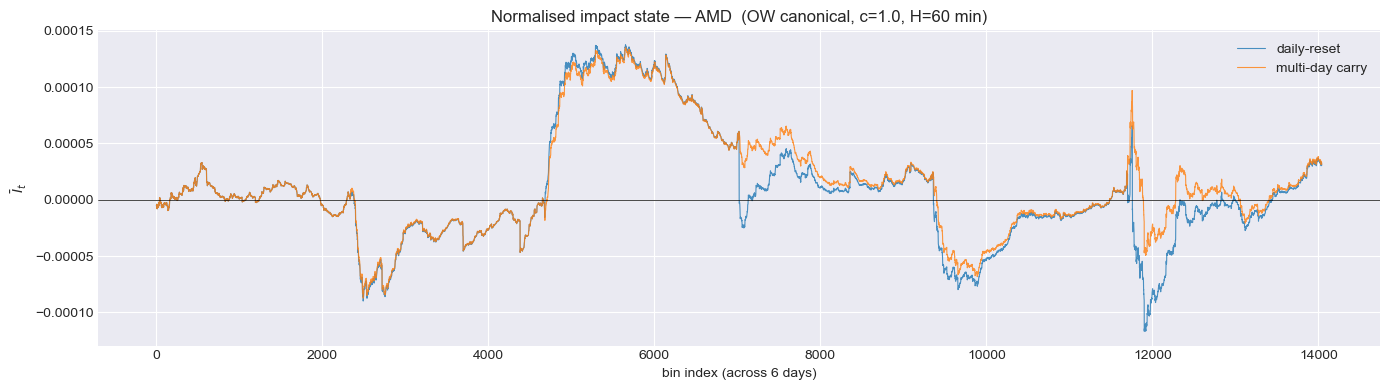

In [24]:
# Quick visual: daily-reset vs multi-day Ī for one (stock, range of dates).
stock_demo = panel.stocks[0]
sample = (
    imp[imp["stock"] == stock_demo].sort_values(["date", "time"]).head(2340 * 6)
)  # ~6 days
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["I_bar_daily"].values, lw=0.8, label="daily-reset", alpha=0.8)
ax.plot(sample["I_bar_multi"].values, lw=0.8, label="multi-day carry", alpha=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(
    f"Normalised impact state — {stock_demo}  (OW canonical, c=1.0, H={H_FIT:.0f} min)"
)
ax.set_xlabel("bin index (across 6 days)")
ax.set_ylabel(r"$\bar I_t$")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Impact Model Fitting — Extended Analysis

Per Anran's Section 2.2: rolling per-stock OLS of $y_t = \alpha + \lambda x_t$ where

$$ y_t = (P_t - P_{t-\tau})/P_{t-\tau}, \qquad x_t = \bar I_t - \bar I_{t-\tau}. $$

The same machinery works on **either** carry mode — set `carry='daily'` or `carry='multi'` and the fitter consumes the right $\bar I$ column.


### 3.1 Half-life grid search


In [ ]:
# Half-life grid search via concavity_grid_search (uses the canonical
# compute_impact_states under the hood).
H_GRID = [5, 10, 20, 30, 45, 60, 90, 120, 180]
TAU_BINS = 6  # τ = 1 min explanation horizon

grid_df = pi.concavity_grid_search(
    data,
    daily_stats,
    c_grid=list(MODELS.values()),
    H_grid_minutes=H_GRID,
    tau_bins=TAU_BINS,
    carry="daily",
    progress=True,
)
_c_to_name = {c: name for name, c in MODELS.items()}
grid_df["model"] = grid_df["c"].map(_c_to_name)
best_per_model = (
    grid_df.groupby(["model", "H"])["oos_r2"]
    .mean()
    .reset_index()
    .sort_values(["model", "oos_r2"], ascending=[True, False])
)
print(best_per_model.groupby("model").head(3).to_string(index=False))

# Continuity choice from the report: fix H* = 52.5 min for both models so
# that the rest of the pipeline matches the report's headline number.
H_star = 52.5
print(f"Adopted H* = {H_star} min  (continuity choice; see report addendum)")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, c_val in MODELS.items():
    sub = grid_df[grid_df["c"] == c_val].groupby("H")["oos_r2"].mean()
    ax.plot(sub.index, sub.values, "o-", lw=2, label=f"{name} (c={c_val})")
ax.axvline(H_star, ls="--", color="black", label=f"H* = {H_star} min (continuity)")
ax.set_xlabel("Half-life H (minutes)")
ax.set_ylabel("Mean OOS R²")
ax.set_title("Half-life grid — canonical AFS family (concavity outside the OU)")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
TAU_BINS = 6
H_star = 52.5

### 3.2 Parametric rolling baseline — both carry modes


In [25]:
# Recompute canonical impact panels at H* and fit on both carry modes.
impact_panels_star = {
    name: pi.compute_impact_states(
        data,
        daily_stats,
        half_life_minutes=H_star,
        c=c_val,
    )
    for name, c_val in MODELS.items()
}

baseline_results = {}
for name in MODELS:
    for carry in ("daily", "multi"):
        feats = pi.build_regression_features(
            impact_panels_star[name], data, tau_bins=TAU_BINS, carry=carry
        )
        stats = pi.daily_sufficient_stats(feats)
        baseline_results[(name, carry)] = pi.rolling_baseline(
            stats, n_windows=10, offset=2
        )

summary_rows = []
for (name, carry), df in baseline_results.items():
    mean_lam = df["lambda"].mean()
    sd_lam = df["lambda"].std()
    summary_rows.append(
        {
            "model": name,
            "carry": carry,
            "c": MODELS[name],
            "mean_lambda": mean_lam,
            "sd_lambda": sd_lam,
            "t_stat_lambda": mean_lam / sd_lam if sd_lam > 0 else float("nan"),
            "mean_oos_r2": df["oos_r2"].mean(),
            "mean_is_r2": df["is_r2"].mean(),
            "n_rows": len(df),
        }
    )
pd.DataFrame(summary_rows).round(5)

,model,carry,c,mean_lambda,sd_lambda,t_stat_lambda,mean_oos_r2,mean_is_r2,n_rows
0,ow,daily,1.0,316.26564,76.02303,4.16013,0.15042,0.17399,196
1,ow,multi,1.0,314.90009,75.69732,4.15999,0.14965,0.17323,196
2,afs,daily,0.5,48.69768,12.55541,3.87862,0.11001,0.11849,196
3,afs,multi,0.5,49.28001,12.56479,3.92207,0.10459,0.11254,196


### 3.3 Non-parametric binned extension


In [26]:
# Per-stock binned g(x) shrunk toward a universal curve; γ tuned on the
# month immediately after the training month, OOS scored on m + 2.
feats_ow = pi.build_regression_features(
    impact_panels_star["ow"], data, tau_bins=TAU_BINS, carry="daily"
)
feats_afs = pi.build_regression_features(
    impact_panels_star["afs"], data, tau_bins=TAU_BINS, carry="daily"
)

np_ow, fits_ow = pi.rolling_nonparametric(feats_ow, n_bins=15, n_windows=10)
np_afs, fits_afs = pi.rolling_nonparametric(feats_afs, n_bins=15, n_windows=10)

comparison = (
    pd.concat([np_ow.assign(model="ow"), np_afs.assign(model="afs")])
    .groupby("model")[["oos_r2_raw", "oos_r2_univ", "oos_r2_reg"]]
    .mean()
)
print("OOS R² (mean over windows):")
print(comparison.round(5))

OOS R² (mean over windows):
       oos_r2_raw  oos_r2_univ  oos_r2_reg
model                                     
afs       0.21699      0.20477     0.21738
ow        0.23235      0.22094     0.23254


In [ ]:
# Estimated canonical g(x) curves for one window (train month = 3).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name, fits in zip(axes, ["ow", "afs"], [fits_ow, fits_afs]):
    if 3 not in fits:
        ax.set_title(f"{name}: no fit for month 3")
        continue
    f = fits[3]
    edges = f.bin_edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    centers[0] = edges[1] - (edges[2] - edges[1])
    centers[-1] = edges[-2] + (edges[-2] - edges[-3])
    for stock, g in f.reg_best.groupby("stock"):
        ax.plot(centers[g["bin"]], g["g_reg"], "o-", lw=0.6, alpha=0.3)
    ax.plot(
        centers,
        f.g_bar.reindex(range(len(centers))).values,
        "k-",
        lw=2,
        label="universal $\\bar g(x)$",
    )
    ax.set_xlabel(r"$x = \Delta \bar I$")
    ax.set_ylabel(r"$g(x)$")
    ax.set_title(f"{name} (c={MODELS[name]}): non-parametric $g(x)$  (train m=3)")
    ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Per-stock λ for the backtest


In [27]:
# Mean λ over rolling windows per (model, carry); feeds the backtest configs.
lam_lookup_daily = {
    name: pi.per_stock_lambda(baseline_results[(name, "daily")]).to_dict()
    for name in MODELS
}
lam_lookup_multi = {
    name: pi.per_stock_lambda(baseline_results[(name, "multi")]).to_dict()
    for name in MODELS
}

print("Per-stock λ (OW, daily-reset) stats:")
print(
    pi.per_stock_lambda_stats(baseline_results[("ow", "daily")])
    .sort_values("mean")
    .round(5)
    .to_string()
)
print("\nPer-stock λ (AFS, daily-reset) stats:")
print(
    pi.per_stock_lambda_stats(baseline_results[("afs", "daily")])
    .sort_values("mean")
    .round(5)
    .to_string()
)

Per-stock λ (OW, daily-reset) stats:
            mean       std    t_stat
stock                               
AES    198.35532  14.12865  14.03922
AEP    248.82101  87.71716   2.83663
AAL    250.06622  58.21837   4.29531
AMAT   279.19187  56.13314   4.97374
APC    282.19972  80.94098   3.48649
ADI    284.24948  35.79385   7.94129
ADP    294.20695  49.33533   5.96341
AOS    302.84826  63.54158   4.76614
ADSK   314.52880  68.78378   4.57272
ABT    319.76187  54.18927   5.90083
ADM    328.23978  24.78439  13.24381
AIG    329.60403  66.57650   4.95076
ABBV   330.20301  55.30836   5.97022
APA    335.56552  60.06804   5.58642
ADBE   336.37869  48.82606   6.88933
AMGN   347.92085  59.99081   5.79957
AMD    357.53655  59.81507   5.97737
AFL    357.96571  57.98840   6.17306
AAPL   379.64638  94.13238   4.03311
AMZN   434.39637  48.15061   9.02162

Per-stock λ (AFS, daily-reset) stats:
           mean       std    t_stat
stock                              
AES    34.78958   3.82542   9.09432
AE

## 4. Synthetic Alpha

$\alpha_t = r^h_t + y \, dW_t / P_t$ with $y$ chosen so that $\mathrm{Corr}(\alpha, r^h) = \rho$ **and** $E[r^h | \alpha] = \alpha$.


In [28]:
RHO = 0.05
H_ALPHA_BINS = 6  # next-bin forward return

alphas = pi.create_synthetic_alpha(
    data, rho=RHO, h_bins=H_ALPHA_BINS, seed=42, verbose=False
)
emp = alphas.groupby("stock").apply(lambda g: g["alpha"].corr(g["fwd_ret"]))
print(f"Empirical mean Corr(α, r) = {emp.mean():.4f}  (target ρ = {RHO})")
alphas.head()


Empirical mean Corr(α, r) = 0.0503  (target ρ = 0.05)


,stock,date,time,alpha,fwd_ret
0,AAL,2019-01-02,09:30:00,0.000008,-0.002538
1,AAL,2019-01-02,09:30:10,-0.000051,-0.001269
2,AAL,2019-01-02,09:30:20,0.000030,-0.001744
3,AAL,2019-01-02,09:30:30,0.000037,-0.002380
4,AAL,2019-01-02,09:30:40,-0.000097,-0.002859


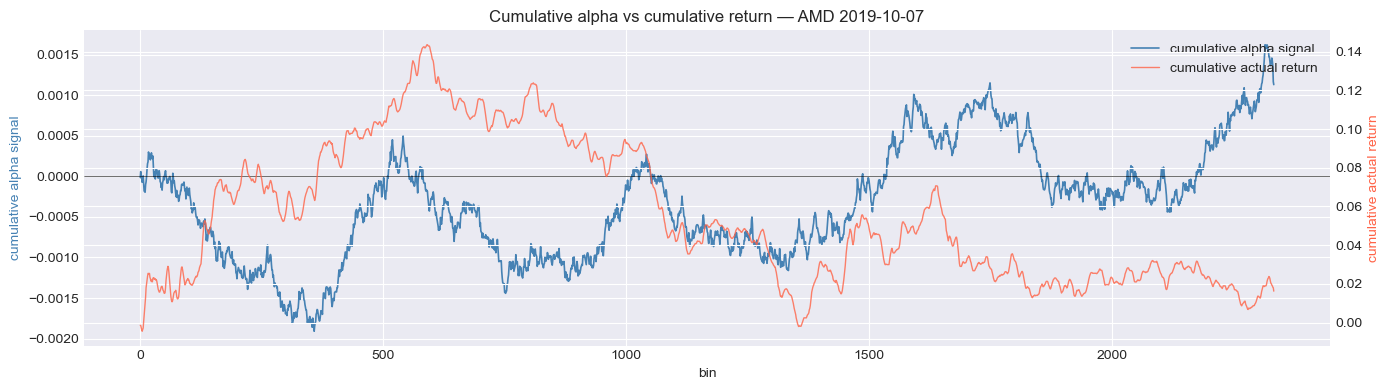

In [29]:
demo_stock = panel.stocks[0]
demo_date = alphas["date"].iloc[len(alphas) // 2]
mask = (alphas["stock"] == demo_stock) & (alphas["date"] == demo_date)
day = alphas.loc[mask].reset_index(drop=True)

cum_alpha = day["alpha"].cumsum()
cum_ret = day["fwd_ret"].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(cum_alpha.values, color="steelblue", lw=1.2, label="cumulative alpha signal")
ax2.plot(
    cum_ret.values, color="tomato", lw=1.0, alpha=0.8, label="cumulative actual return"
)

ax1.axhline(0, color="k", lw=0.4)
ax1.set_xlabel("bin")
ax1.set_ylabel("cumulative alpha signal", color="steelblue")
ax2.set_ylabel("cumulative actual return", color="tomato")
ax1.set_title(
    f"Cumulative alpha vs cumulative return — {demo_stock} {demo_date.date()}"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

### Optimal trading strategies

**OW.** Closed-form OW target position:

$$
X_t^* = \frac{\alpha_t \, ADV}{2 \lambda \sigma}
$$

The position is adjusted at speed

$$
\kappa = \beta = \frac{\log(2)}{H}
$$

with the practical final-30-minute ramp used in the implementation.

**AFS.** With constant alpha, the AFS target is set in impact space:

$$
I_t^* = \frac{\alpha_t}{1+c}
$$

Since realized impact is $I_t = \lambda \bar I_t$, the normalized target state is

$$
\bar I_t^* = \frac{\alpha_t}{(1+c)\lambda}
$$

For sqrt AFS, $c = 0.5$, so $I_t^* = 2\alpha_t/3$. Trades are recovered by inverting the normalized square-root recursion:

$$
\bar I_t = (1-\beta)\bar I_{t-1}
+ \sigma \, \mathrm{sign}(q_t)
\sqrt{\frac{|q_t|}{ADV}}
$$

Define

$$
z_t = \bar I_t^* - (1-\beta)\bar I_{t-1}
$$

Then the AFS trade per bin is

$$
q_t^* = ADV \, \mathrm{sign}(z_t)
\left(\frac{|z_t|}{\sigma}\right)^2
$$

The same practical end-of-day ramp convention is applied as in OW.

AMD 2019-10-07:  OW Σ|q| = 2247332, AFS Σ|q| = 38845


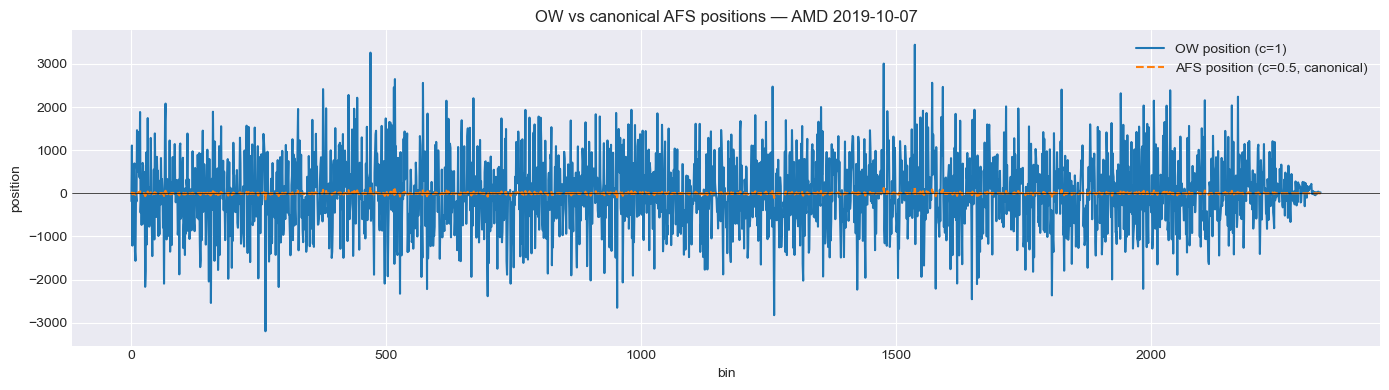

In [30]:
# Sanity check on a synthetic-alpha day with the canonical strategies.
demo_stock = panel.stocks[0]
demo_date = alphas["date"].iloc[len(alphas) // 2]
mask = (alphas["stock"] == demo_stock) & (alphas["date"] == demo_date)
alpha_demo = alphas.loc[mask, "alpha"].values
stats_demo = daily_stats.loc[(demo_stock, demo_date)]

q_ow = pi.ow_optimal_strategy(
    alpha_demo,
    stats_demo["sigma"],
    stats_demo["ADV"],
    lam=lam_lookup_daily["ow"][demo_stock],
    half_life_minutes=H_star,
)
q_afs = pi.afs_optimal_strategy(
    alpha_demo,
    stats_demo["sigma"],
    stats_demo["ADV"],
    lam=lam_lookup_daily["afs"][demo_stock],
    half_life_minutes=H_star,
    c=C_AFS,
)
print(
    f"{demo_stock} {demo_date.date()}:  "
    f"OW Σ|q| = {np.sum(np.abs(q_ow)):.0f}, AFS Σ|q| = {np.sum(np.abs(q_afs)):.0f}"
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(np.cumsum(q_ow), label="OW position (c=1)")
ax.plot(np.cumsum(q_afs), label=f"AFS position (c={C_AFS}, canonical)", ls="--")
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"OW vs canonical AFS positions — {demo_stock} {demo_date.date()}")
ax.set_xlabel("bin")
ax.set_ylabel("position")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Backtest Engine

Waelbroeck construction with explicit flow accounting:

$$ q_{others,t} = q_{agg,t} - q_{us,t}, \qquad g_{others}(t)=\lambda\bar I(q_{others})(t), \qquad g_{full}(t)=\lambda\bar I(q_{agg})(t). $$

Both price paths share the same baseline cumulative return $R(t)$ from the day-open mid:

$$ P_{unpert}(t)=P_0\bigl(1+R(t)+g_{others}(t)\bigr), \qquad P_{pert}(t)=P_0\bigl(1+R(t)+g_{full}(t)\bigr). $$

The incremental model impact of our trading is $\Delta g(t)=g_{full}(t)-g_{others}(t)$. Mark-to-market net P&L uses `P_pert`; the no-us benchmark uses `P_unpert`; raw observed mid P&L is retained only as a diagnostic. Participation is computed from `abs(q_us) / abs(trade)` per bin and from turnover over day volume.

`run_backtest` accepts **any** signed trade path through a `trade_provider` callable; pass `make_optimal_provider(...)` for OW/AFS, or `make_fixed_provider(...)` for TWAP / VWAP demos. Carry mode is `daily` or `multi`: daily resets impact to zero at each open, while multi-day starts `I_others` and `I_full` exactly where they ended on the previous trading day, with no overnight impact decay.

Reality check: `P_unpert` is a Waelbroeck-consistent counterfactual, not an observed no-us mid. The rolling-stat functions can consume `price_col="p_unpert"` when such a panel exists; the first-pass historical calibration here remains mid-based and is therefore an explicit hybrid.


## 7. Results — Modular Backtest Sweep

We compare four configurations along two axes — model (OW vs AFS) × carry mode (daily-reset vs multi-day). Each run produces:

- per-day P&L on `P_pert` and `P_unpert`, plus raw-mid diagnostics;
- turnover, realised participation, max with-us/no-us impact dislocation, and flow-accounting flags where `abs(q_us) > abs(q_agg)` in a bin;
- TCA decomposition (net P&L, gross no-us P&L, impact cost, predicted α reward, realised α reward);
- cumulative-P&L, drawdown, and impact-dislocation plots.

All artifacts land in `saved/<name>/`.


In [31]:
RHO_HIGH = 0.1
H_ALPHA_BINS = 6

ow_daily                        Sharpe(pert)=+30.520  net P&L=$     1,521,009  impact cost=$     2,860,119  participation=44.7548%  flow flags=1703526
afs_daily                       Sharpe(pert)=+28.272  net P&L=$        22,090  impact cost=$           713  participation=0.8201%  flow flags=467219
ow_daily_high                   Sharpe(pert)=+35.311  net P&L=$     6,061,084  impact cost=$    11,368,765  participation=89.2311%  flow flags=2769738
afs_daily_high                  Sharpe(pert)=+35.407  net P&L=$       178,479  impact cost=$        11,357  participation=3.2719%  flow flags=579557


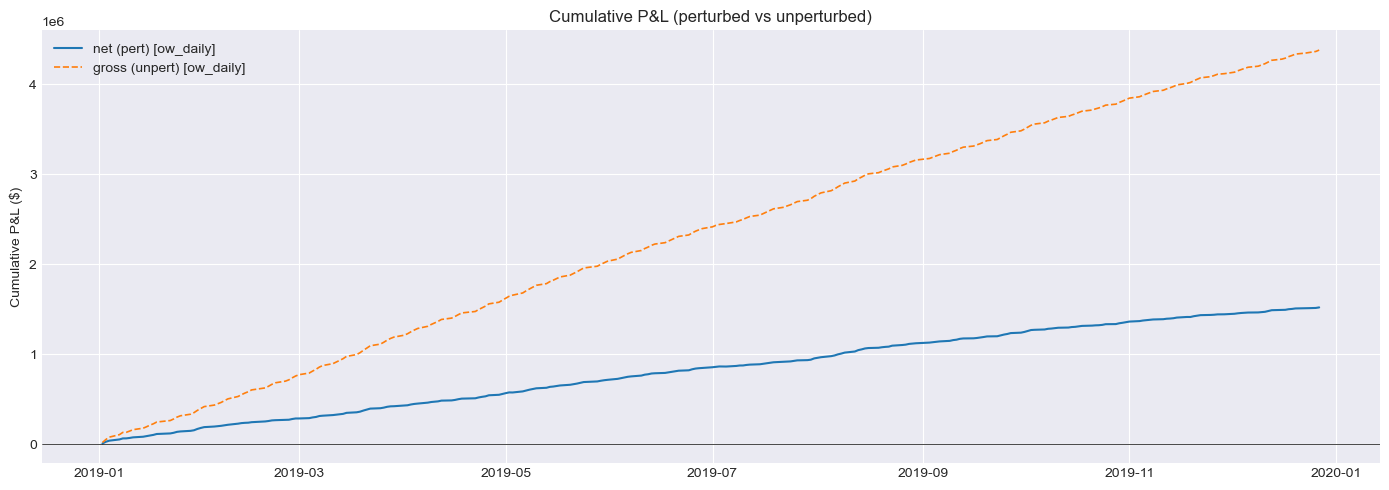

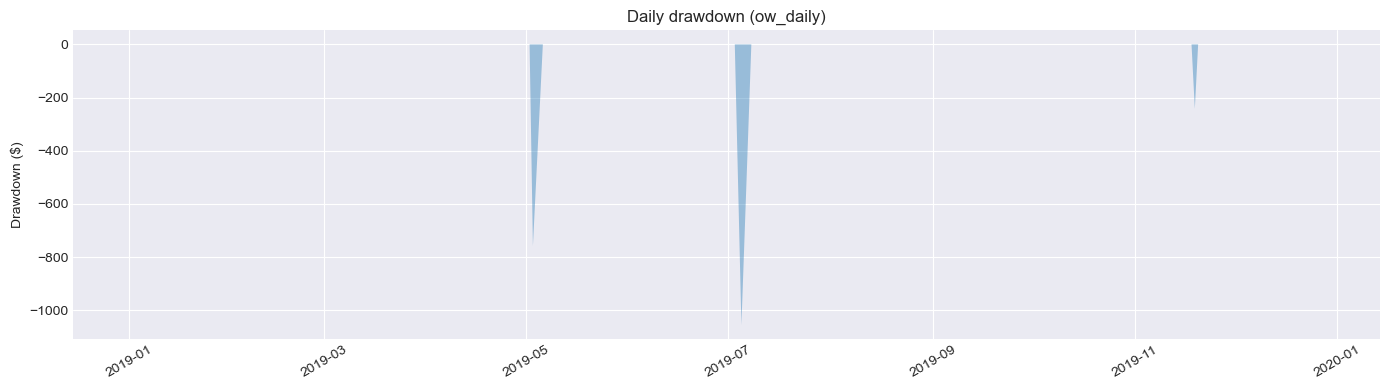

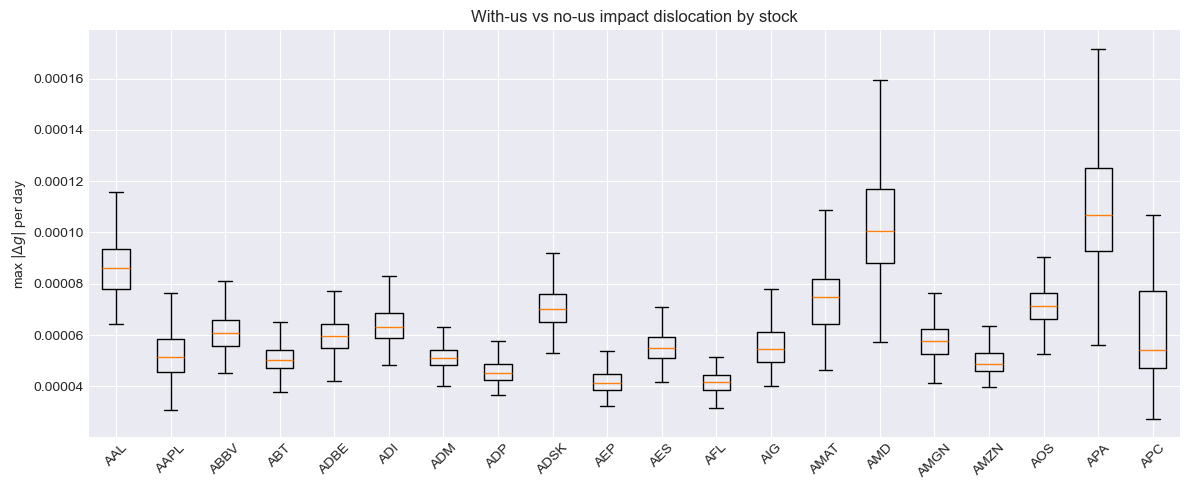

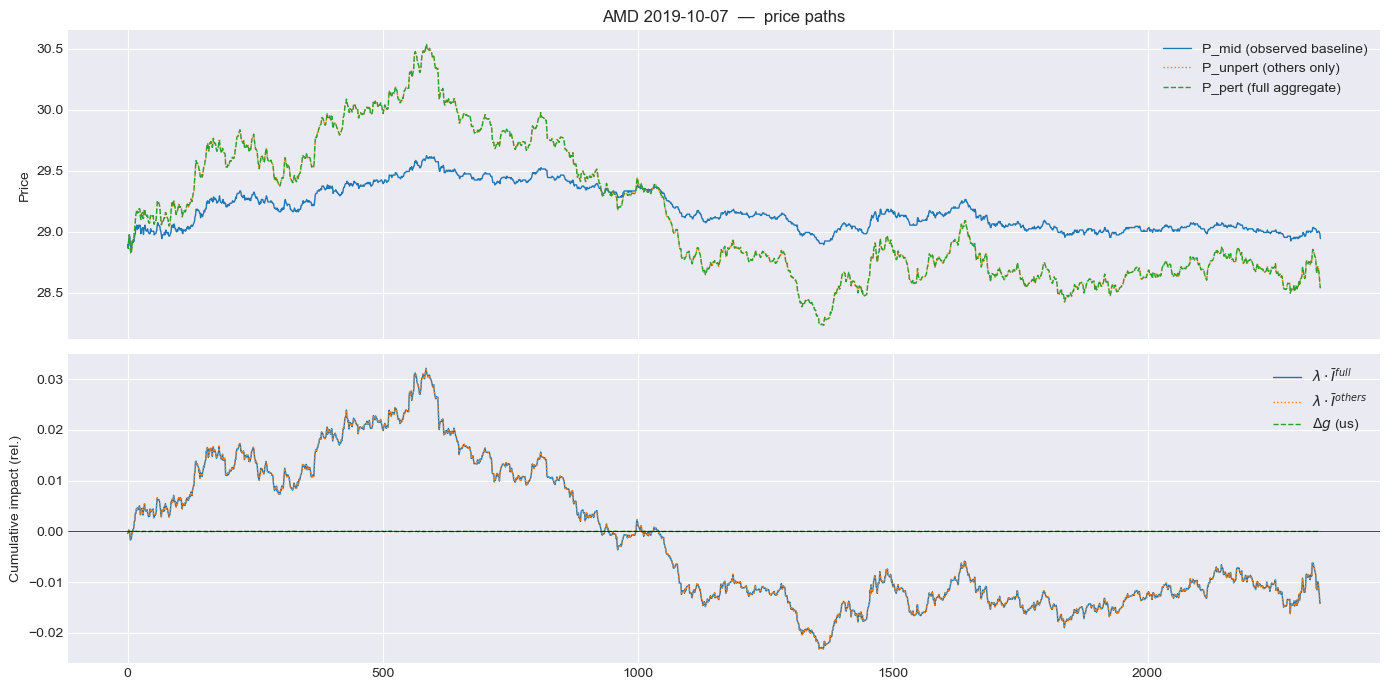

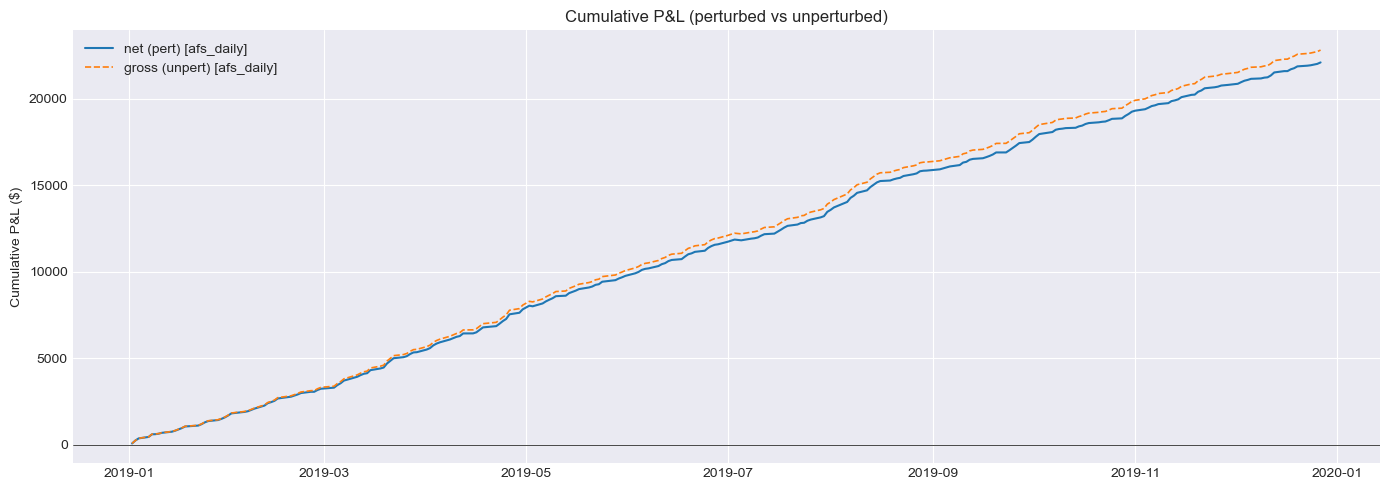

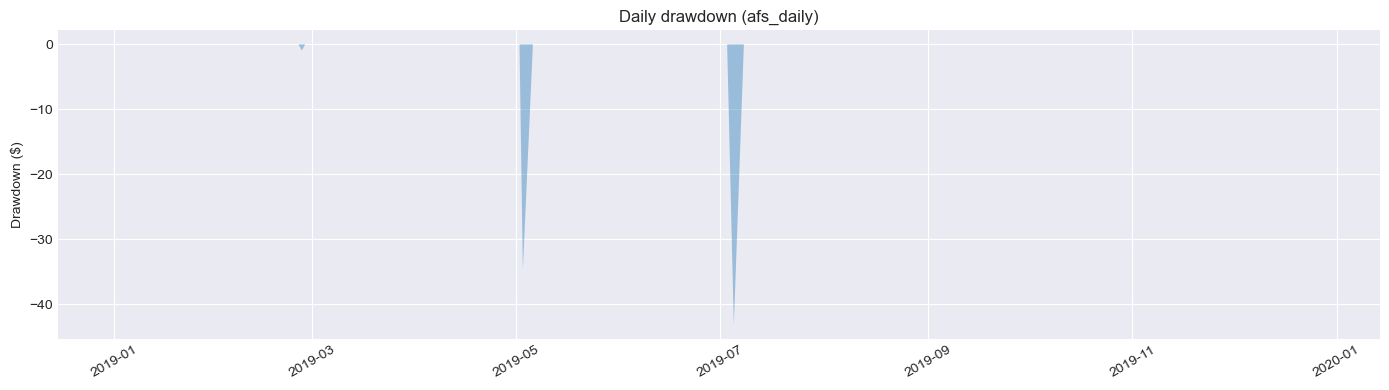

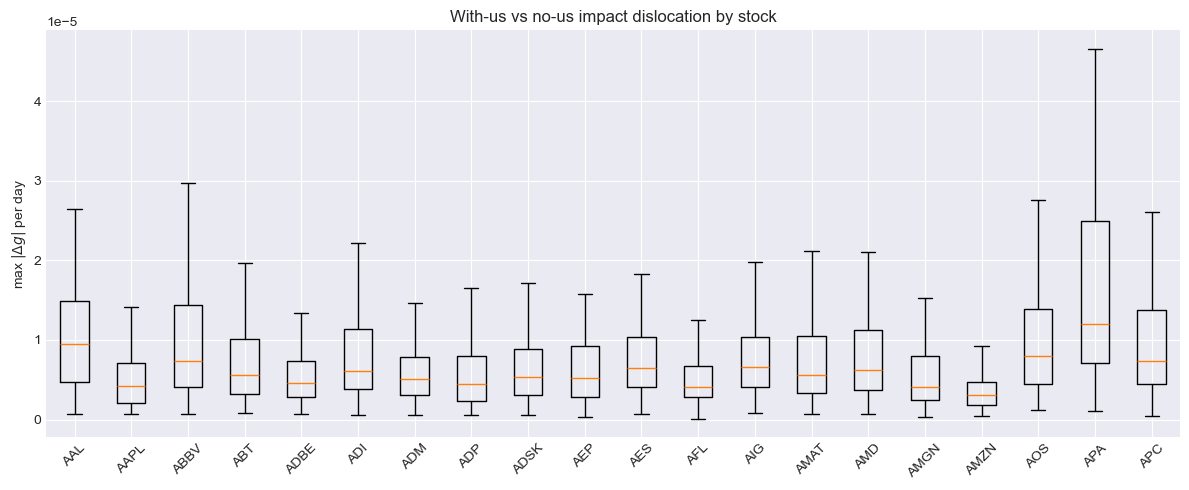

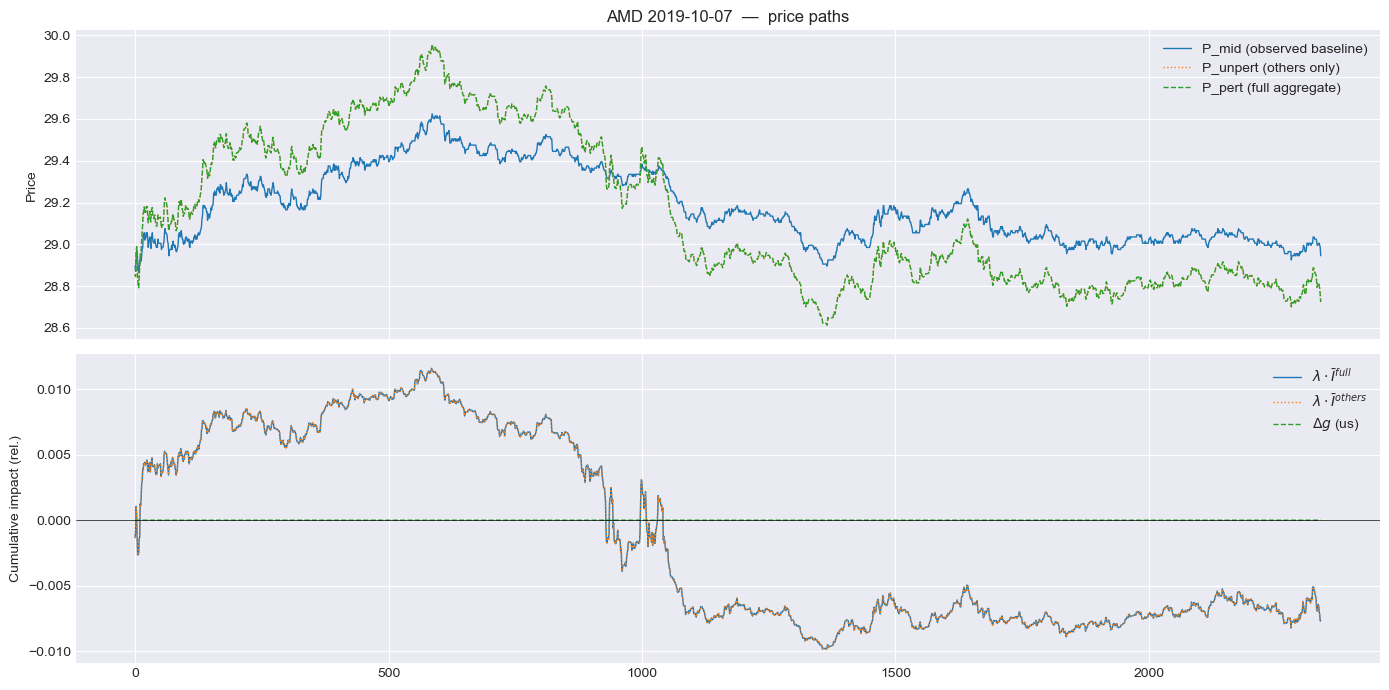

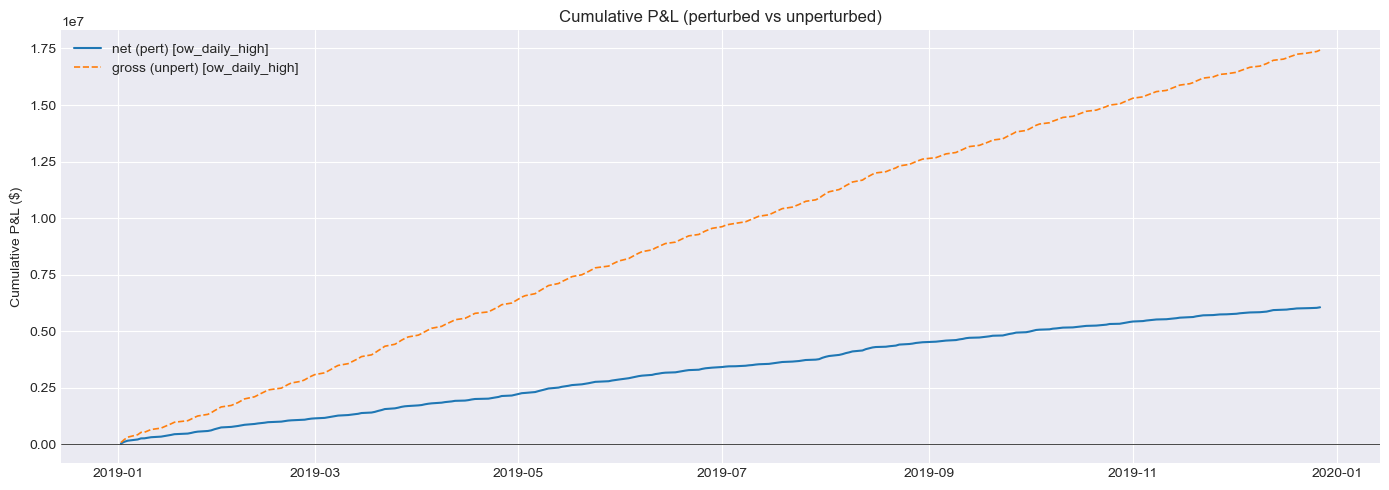

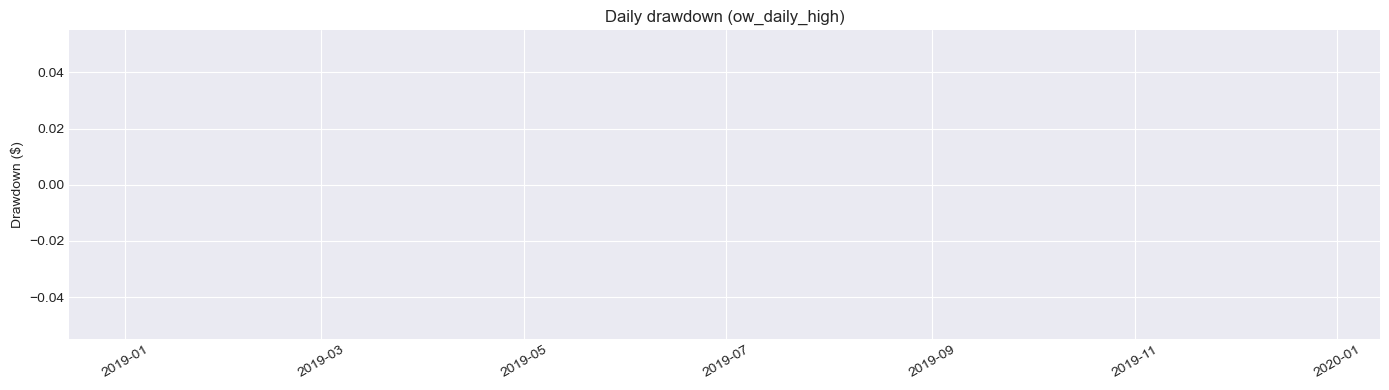

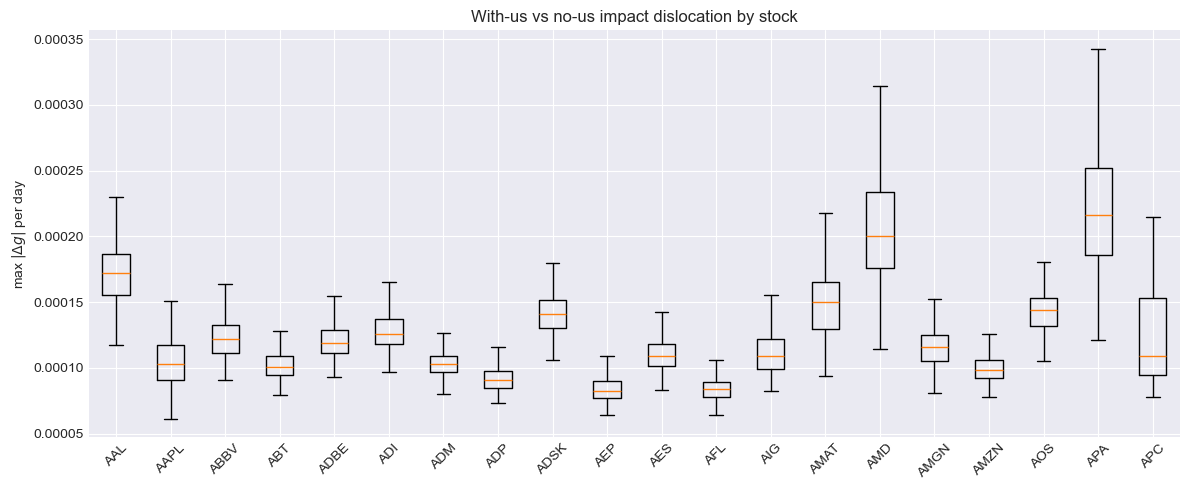

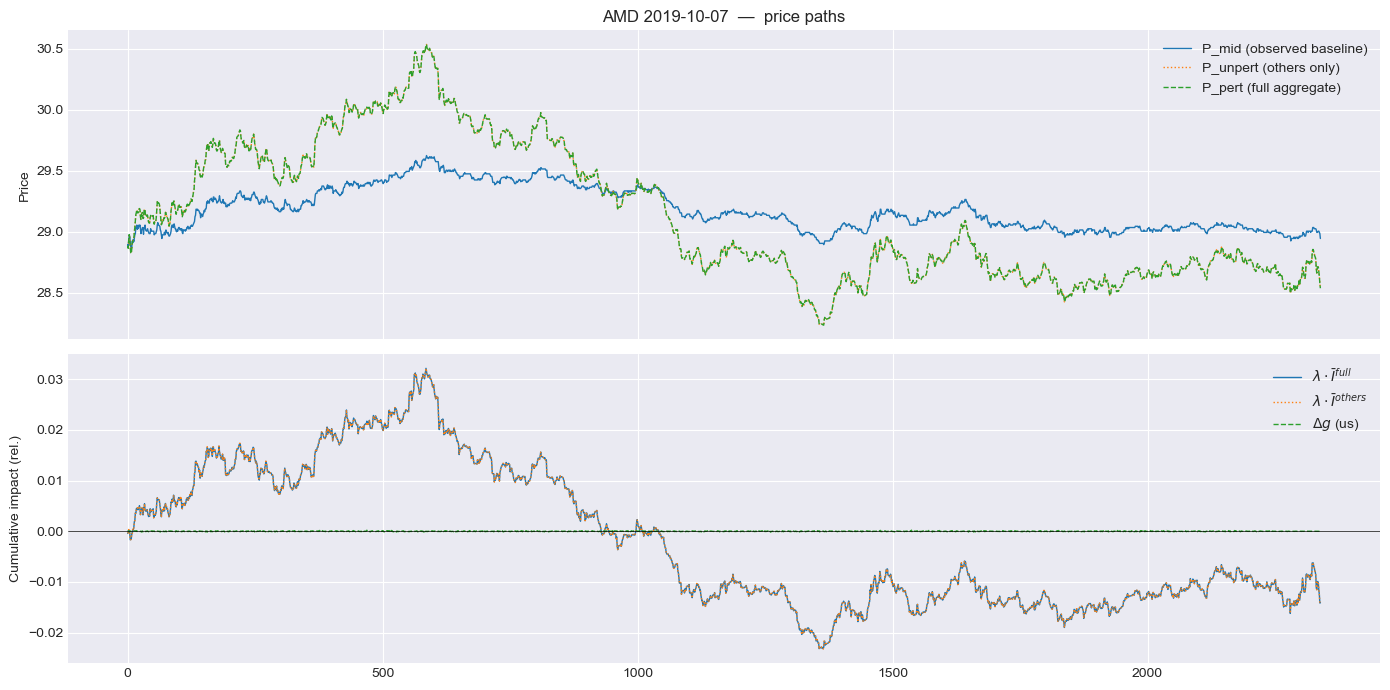

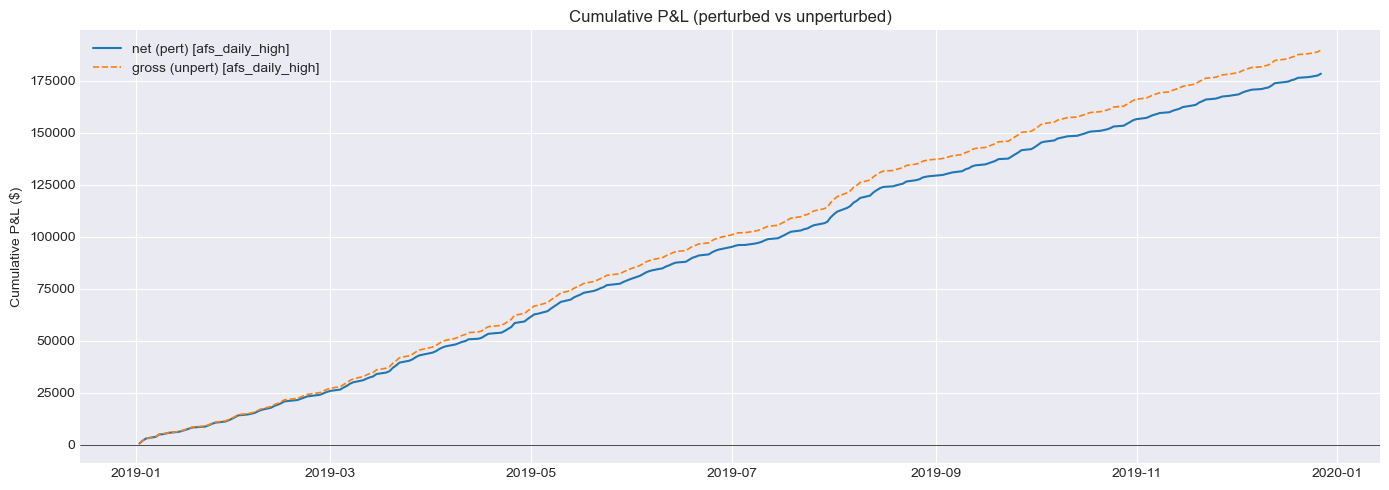

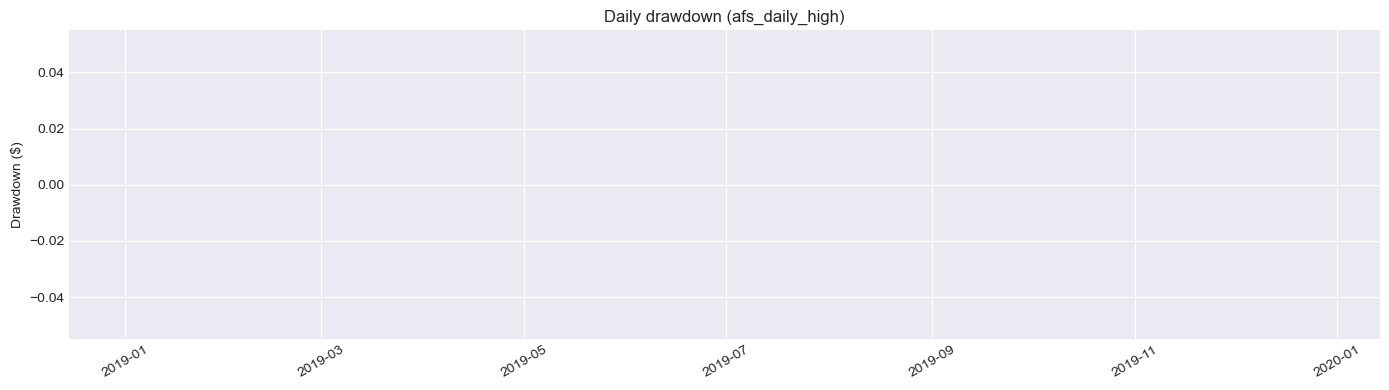

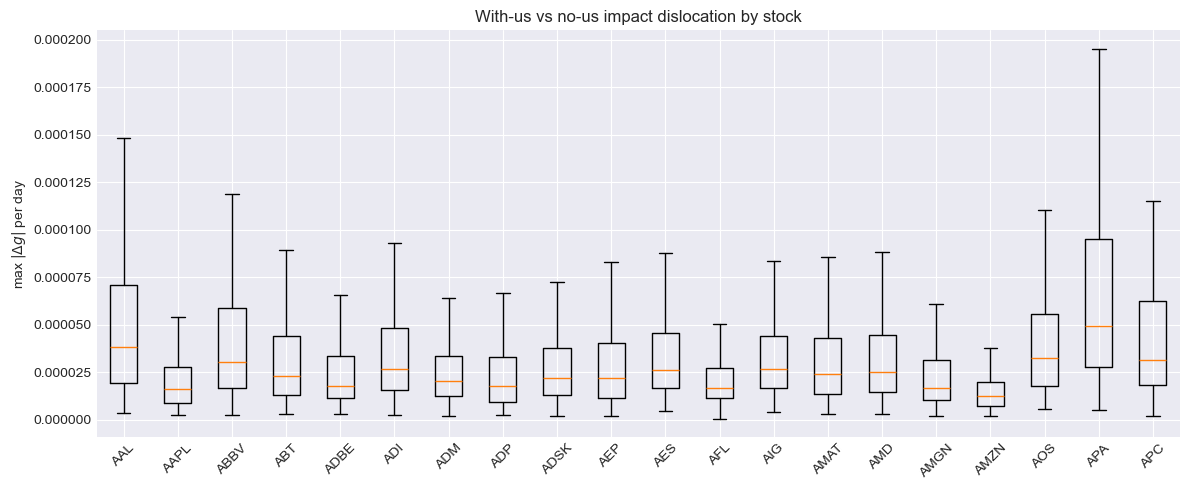

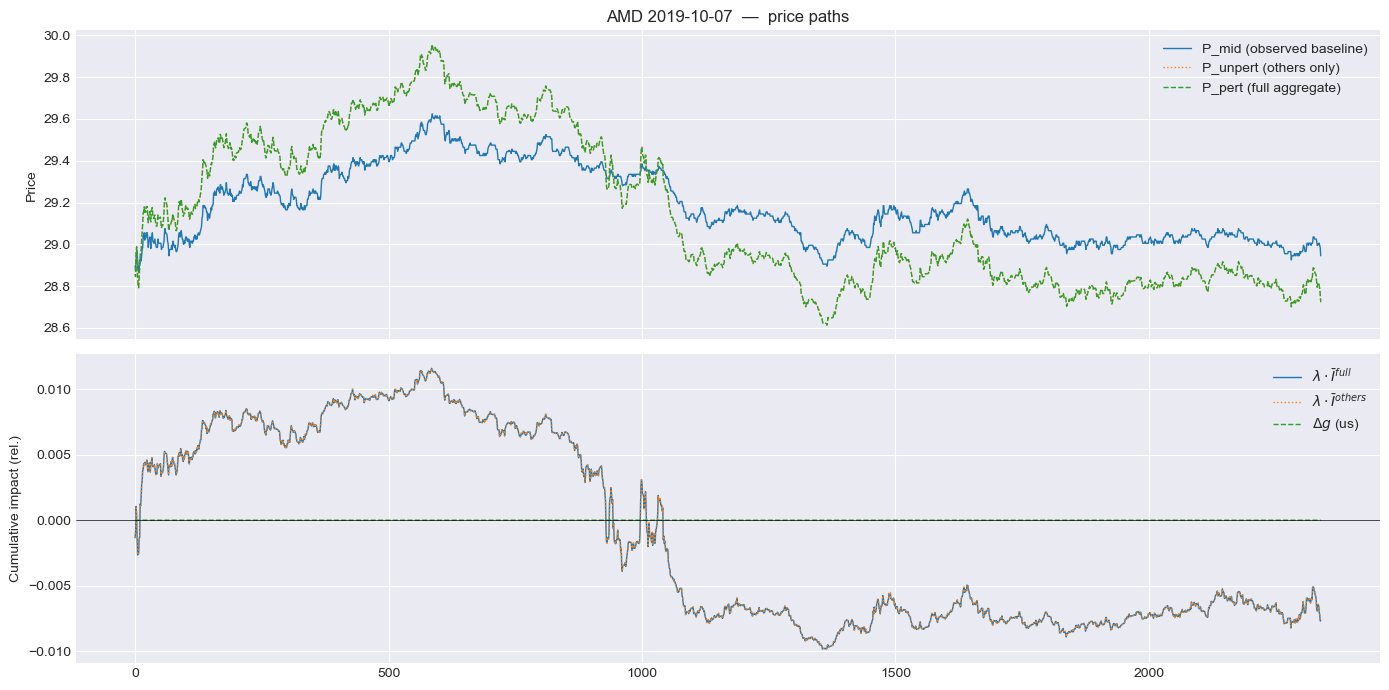

In [32]:
configs = [
    pi.BacktestConfig(
        name="ow_daily",
        model_type="linear",
        strategy="ow",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    # pi.BacktestConfig(
    #     name="ow_multi",
    #     model_type="linear",
    #     strategy="ow",
    #     carry="multi",
    #     half_life_minutes=H_star,
    #     tau_bins=TAU_BINS,
    #     rho=RHO,
    #     h_alpha_bins=H_ALPHA_BINS,
    # ),
    pi.BacktestConfig(
        name="afs_daily",
        model_type="sqrt",
        strategy="afs",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    # pi.BacktestConfig(
    #     name="afs_multi",
    #     model_type="sqrt",
    #     strategy="afs",
    #     carry="multi",
    #     half_life_minutes=H_star,
    #     tau_bins=TAU_BINS,
    #     rho=RHO,
    #     h_alpha_bins=H_ALPHA_BINS,
    # ),
    pi.BacktestConfig(
        name="ow_daily_high",
        model_type="linear",
        strategy="ow",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO_HIGH,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    # pi.BacktestConfig(
    #     name="ow_multi_high",
    #     model_type="linear",
    #     strategy="ow",
    #     carry="multi",
    #     half_life_minutes=H_star,
    #     tau_bins=TAU_BINS,
    #     rho=RHO_HIGH,
    #     h_alpha_bins=H_ALPHA_BINS,
    # ),
    pi.BacktestConfig(
        name="afs_daily_high",
        model_type="sqrt",
        strategy="afs",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO_HIGH,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    # pi.BacktestConfig(
    #     name="afs_multi_high",
    #     model_type="sqrt",
    #     strategy="afs",
    #     carry="multi",
    #     half_life_minutes=H_star,
    #     tau_bins=TAU_BINS,
    #     rho=RHO_HIGH,
    #     h_alpha_bins=H_ALPHA_BINS,
    # ),
    # pi.BacktestConfig(
    #     name="afs_pi_ow_strat_daily",
    #     model_type="sqrt",
    #     strategy="ow",
    #     carry="daily",
    #     half_life_minutes=H_star,
    #     tau_bins=TAU_BINS,
    #     rho=RHO,
    #     h_alpha_bins=H_ALPHA_BINS,
    # ),
    # pi.BacktestConfig(
    #     name="afs_pi_ow_strat_multi",
    #     model_type="sqrt",
    #     strategy="ow",
    #     carry="multi",
    #     half_life_minutes=H_star,
    #     tau_bins=TAU_BINS,
    #     rho=RHO,
    #     h_alpha_bins=H_ALPHA_BINS,
    # ),
    # pi.BacktestConfig(
    #     name="ow_pi_afs_strat_daily",
    #     model_type="linear",
    #     strategy="afs",
    #     carry="daily",
    #     half_life_minutes=H_star,
    #     tau_bins=TAU_BINS,
    #     rho=RHO,
    #     h_alpha_bins=H_ALPHA_BINS,
    # ),
    # pi.BacktestConfig(
    #     name="ow_pi_afs_strat_multi",
    #     model_type="linear",
    #     strategy="afs",
    #     carry="multi",
    #     half_life_minutes=H_star,
    #     tau_bins=TAU_BINS,
    #     rho=RHO,
    #     h_alpha_bins=H_ALPHA_BINS,
    # ),
]

_alpha_cache: dict[tuple, pd.DataFrame] = {}
runs = {}
for cfg in configs:
    alpha_key = (cfg.rho, cfg.h_alpha_bins, cfg.seed)
    if alpha_key not in _alpha_cache:
        _alpha_cache[alpha_key] = pi.create_synthetic_alpha(
            data, rho=cfg.rho, h_bins=cfg.h_alpha_bins, seed=cfg.seed, verbose=False
        )
    cfg_alphas = _alpha_cache[alpha_key]
    lam_key = "ow" if cfg.strategy == "ow" else "afs"
    lam_lookup = (lam_lookup_daily if cfg.carry == "daily" else lam_lookup_multi)[
        lam_key
    ]
    sample_day = (panel.stocks[0], cfg_alphas["date"].iloc[len(cfg_alphas) // 2])
    out = pi.run_and_save(
        data,
        daily_stats,
        cfg_alphas,
        lam_lookup,
        cfg,
        sample_path=sample_day,
    )
    runs[cfg.name] = out
    print(
        f"{cfg.name:30s}  Sharpe(pert)={out.metrics['sharpe_pert']:+.3f}  "
        f"net P&L=${out.metrics['total_pnl_pert']:>14,.0f}  "
        f"impact cost=${out.metrics['total_impact_cost']:>14,.0f}  "
        f"participation={out.metrics['realized_participation']:.4%}  "
        f"flow flags={out.metrics['flow_flag_count']:d}"
    )

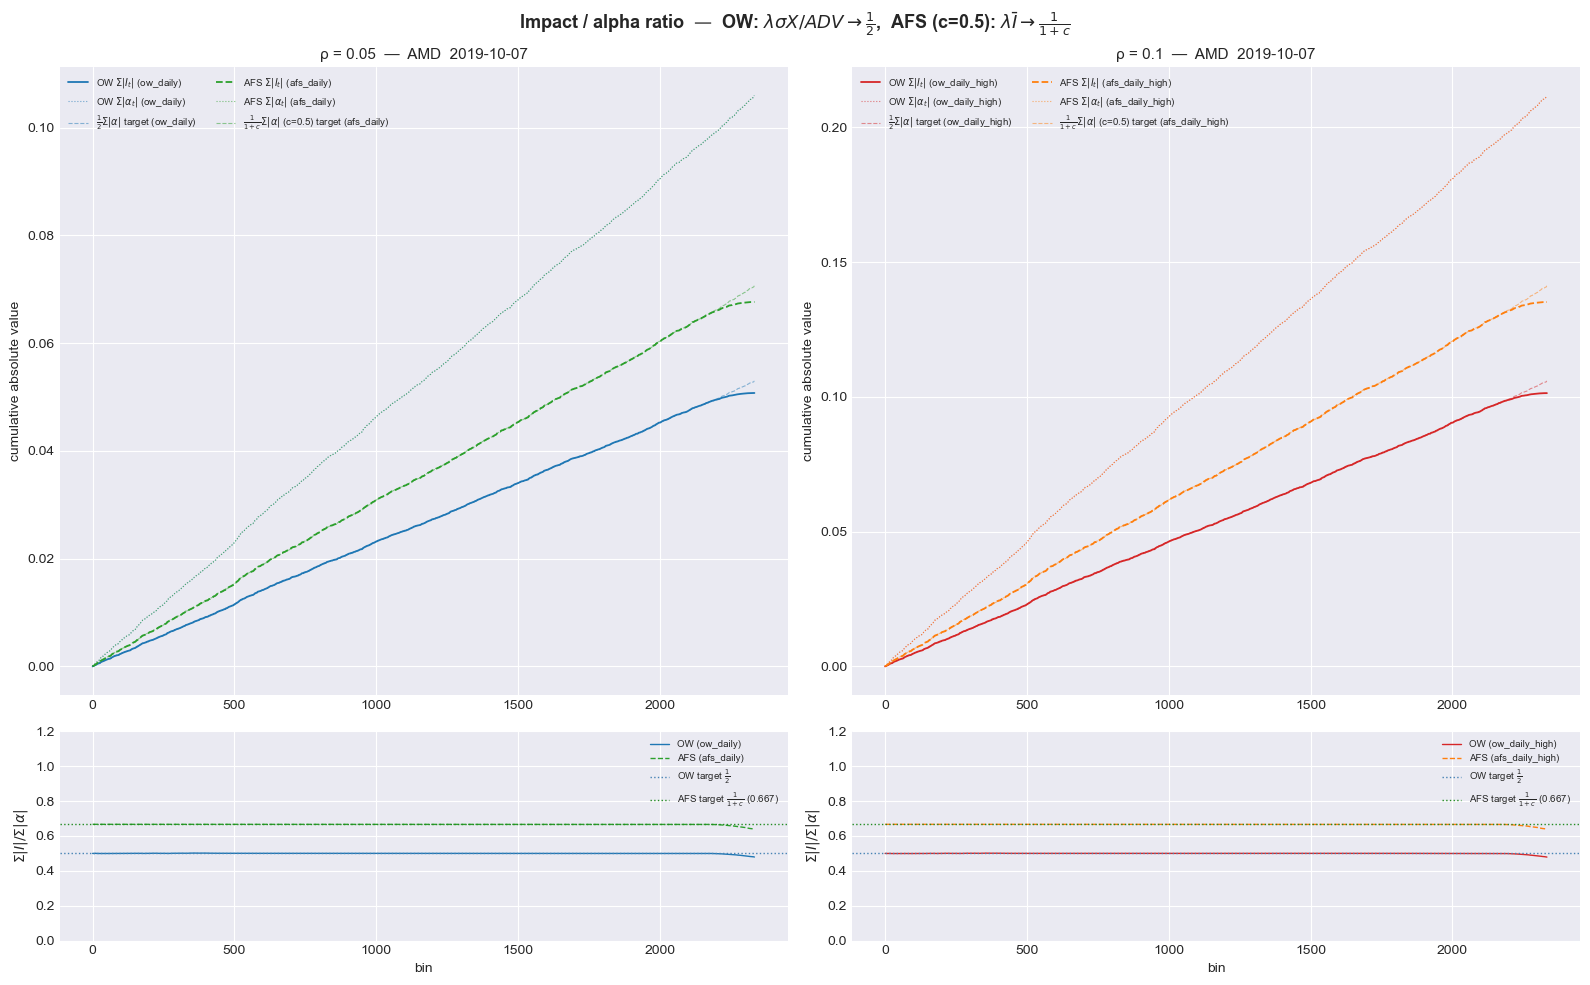

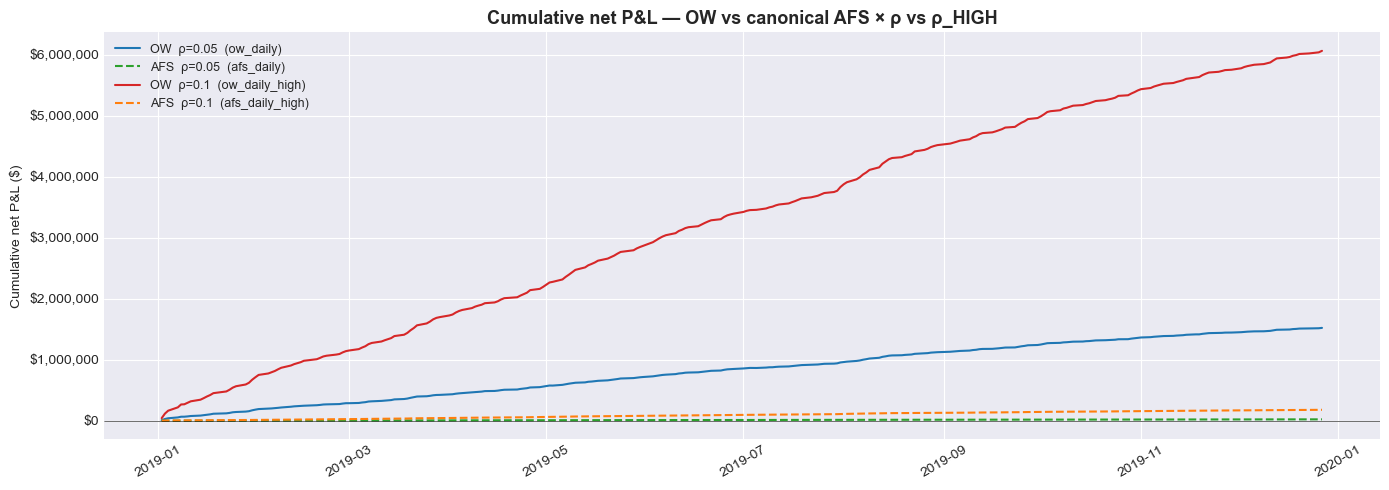

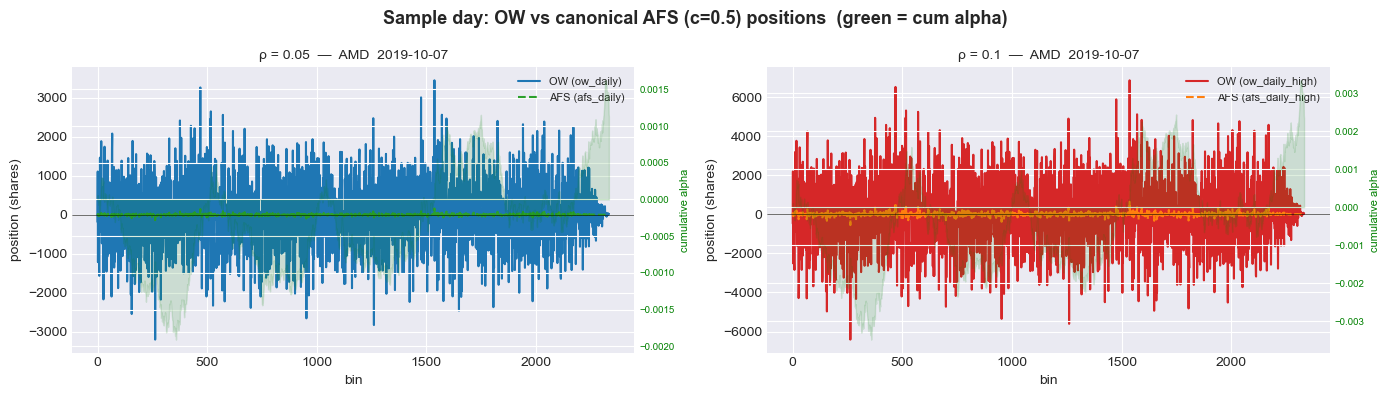

In [33]:
# ─── ρ sensitivity deep-dive: impact/alpha ratio, P&L, sample-day positions ───
import matplotlib.ticker as mtick

# Four configs grouped by ρ level; within each group OW=solid, AFS=dashed.
# Colors: blue family = low ρ, red/orange family = high ρ.
_RHO_GROUPS = [
    (
        RHO,
        [
            (
                "ow_daily",
                "#1f77b4",
                "-",
                "OW",
                pi.ow_optimal_strategy,
                lam_lookup_daily["ow"],
            ),
            (
                "afs_daily",
                "#2ca02c",
                "--",
                "AFS",
                pi.afs_optimal_strategy,
                lam_lookup_daily["afs"],
            ),
        ],
    ),
    (
        RHO_HIGH,
        [
            (
                "ow_daily_high",
                "#d62728",
                "-",
                "OW",
                pi.ow_optimal_strategy,
                lam_lookup_daily["ow"],
            ),
            (
                "afs_daily_high",
                "#ff7f0e",
                "--",
                "AFS",
                pi.afs_optimal_strategy,
                lam_lookup_daily["afs"],
            ),
        ],
    ),
]

_ALL_CONFIGS = [
    ("ow_daily", RHO, "#1f77b4", "-", _alpha_cache[(RHO, H_ALPHA_BINS, 42)]),
    ("afs_daily", RHO, "#2ca02c", "--", _alpha_cache[(RHO, H_ALPHA_BINS, 42)]),
    (
        "ow_daily_high",
        RHO_HIGH,
        "#d62728",
        "-",
        _alpha_cache[(RHO_HIGH, H_ALPHA_BINS, 42)],
    ),
    (
        "afs_daily_high",
        RHO_HIGH,
        "#ff7f0e",
        "--",
        _alpha_cache[(RHO_HIGH, H_ALPHA_BINS, 42)],
    ),
]

# ─── Helpers ──────────────────────────────────────────────────────────────────
_H_bins = H_star * 6  # bins per half-life
_decay_v = 1.0 - np.log(2.0) / _H_bins  # OU decay per bin
_C_AFS = MODELS["afs"]


def _ou_state(qtilde, decay):
    """OU recursion: state_t = decay·state_{t-1} + qtilde_t, starting from 0."""
    out = np.empty_like(qtilde)
    s = 0.0
    for t in range(len(qtilde)):
        s = decay * s + qtilde[t]
        out[t] = s
    return out


def _bin_ratio(s_alpha, sig, adv, lam, is_ow, fn):
    """Per-bin running ratio Σ|I_t| / Σ|α_t| for one (stock, day).

    OW  (linear): I_t = λ σ X_t / ADV   (position-implied impact)
    AFS (canonical, c): I_t = λ · σ · sign(J_t) · |J_t|^c   where J_t = OU(q/ADV)
    """
    kwargs = dict(half_life_minutes=H_star)
    if not is_ow:
        kwargs["c"] = _C_AFS
    q = fn(s_alpha, sig, adv, lam, **kwargs)
    if is_ow:
        I_arr = lam * sig * np.cumsum(q) / adv
    else:
        # Canonical AFS impact state: J = OU(q/ADV); Ī = σ sign(J)|J|^c
        j_arr = _ou_state(q / adv, _decay_v)
        I_arr = lam * sig * np.sign(j_arr) * np.power(np.abs(j_arr), _C_AFS)
    cum_a = np.cumsum(np.abs(s_alpha))
    cum_I = np.cumsum(np.abs(I_arr))
    return cum_a, cum_I, cum_I / np.where(cum_a > 1e-20, cum_a, np.nan)


# ─── Figure 1: within-day running ratio Σ|I| / Σ|α| across bins ──────────────
# OW  → I = λσX/ADV (position-implied impact), target = ½
# AFS → I = λĪ      (OU impact state, canonical), target = 1/(1+c) = 2/3 for c=0.5
_s_stock = panel.stocks[0]
_s_date = _alpha_cache[(RHO, H_ALPHA_BINS, 42)]["date"].iloc[
    len(_alpha_cache[(RHO, H_ALPHA_BINS, 42)]) // 2
]
_s_stats = daily_stats.loc[(_s_stock, _s_date)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 1]})

_afs_target_frac = 1.0 / (1.0 + _C_AFS)

for col_idx, (rho, members) in enumerate(_RHO_GROUPS):
    ax_top = axes[0, col_idx]
    ax_bot = axes[1, col_idx]
    alp_df = _alpha_cache[(rho, H_ALPHA_BINS, 42)]
    _mask = (alp_df["stock"] == _s_stock) & (alp_df["date"] == _s_date)
    s_alpha = alp_df.loc[_mask, "alpha"].values

    for name, color, ls, lbl, fn, lam_dict in members:
        is_ow = "ow" in runs[name].config.strategy
        lam = lam_dict[_s_stock]
        sig = float(_s_stats["sigma"])
        adv = float(_s_stats["ADV"])
        cum_a, cum_I, ratio = _bin_ratio(s_alpha, sig, adv, lam, is_ow, fn)

        target_label = (
            r"$\frac{1}{2}\Sigma|\alpha|$"
            if is_ow
            else rf"$\frac{{1}}{{1+c}}\Sigma|\alpha|$ (c={_C_AFS})"
        )
        target_frac = 0.5 if is_ow else _afs_target_frac

        ax_top.plot(
            cum_I, color=color, lw=1.3, ls=ls, label=rf"{lbl} $\Sigma|I_t|$ ({name})"
        )
        ax_top.plot(
            cum_a,
            color=color,
            lw=0.8,
            ls=":",
            alpha=0.6,
            label=rf"{lbl} $\Sigma|\alpha_t|$ ({name})",
        )
        ax_top.plot(
            target_frac * cum_a,
            color=color,
            lw=0.8,
            ls="--",
            alpha=0.5,
            label=f"{target_label} target ({name})",
        )

        ax_bot.plot(ratio, color=color, lw=1.0, ls=ls, label=f"{lbl} ({name})")

    ax_bot.axhline(
        0.5, color="steelblue", lw=1.0, ls=":", label=r"OW target $\frac{1}{2}$"
    )
    ax_bot.axhline(
        _afs_target_frac,
        color="forestgreen",
        lw=1.0,
        ls=":",
        label=rf"AFS target $\frac{{1}}{{1+c}}$ ({_afs_target_frac:.3f})",
    )
    ax_bot.set_ylim(0, 1.2)
    ax_bot.set_xlabel("bin")
    ax_bot.set_ylabel(r"$\Sigma|I| / \Sigma|\alpha|$")
    ax_bot.legend(fontsize=7, loc="upper right")

    ax_top.set_title(rf"ρ = {rho}  —  {_s_stock}  {_s_date.date()}", fontsize=11)
    ax_top.set_ylabel("cumulative absolute value")
    ax_top.legend(fontsize=7, ncol=2)

fig.suptitle(
    r"Impact / alpha ratio  —  OW: $\lambda\sigma X/ADV \to \frac{1}{2}$,"
    rf"  AFS (c={_C_AFS}): $\lambda\bar{{I}} \to \frac{{1}}{{1+c}}$",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# ─── Figure 2: cumulative net P&L — all four configs on one chart ─────────────
fig, ax = plt.subplots(figsize=(14, 5))
for name, rho, col, ls, _ in _ALL_CONFIGS:
    cp = pi.cumulative_pnl(runs[name].daily, "pnl_pert")
    strat = "OW" if "ow" in name.split("_") else "AFS"
    ax.plot(
        cp.index,
        cp.values,
        color=col,
        lw=1.5,
        ls=ls,
        label=f"{strat}  ρ={rho}  ({name})",
    )
ax.axhline(0, color="k", lw=0.4)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))
ax.set_ylabel("Cumulative net P&L ($)")
ax.set_title(
    "Cumulative net P&L — OW vs canonical AFS × ρ vs ρ_HIGH",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# ─── Figure 3: sample day — OW + AFS positions, one panel per ρ ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (rho, members) in zip(axes, _RHO_GROUPS):
    alp_df = _alpha_cache[(rho, H_ALPHA_BINS, 42)]
    _mask = (alp_df["stock"] == _s_stock) & (alp_df["date"] == _s_date)
    _alpha_s = alp_df.loc[_mask, "alpha"].values
    _cum_a = np.cumsum(_alpha_s)

    ax2 = ax.twinx()
    ax2.fill_between(range(len(_cum_a)), _cum_a, alpha=0.13, color="green")
    ax2.set_ylabel("cumulative alpha", color="green", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="green", labelsize=7)

    for name, color, ls, lbl, fn, lam_dict in members:
        is_ow_strat = "ow" in runs[name].config.strategy
        kwargs = dict(half_life_minutes=H_star)
        if not is_ow_strat:
            kwargs["c"] = _C_AFS
        _pos = np.cumsum(
            fn(
                _alpha_s,
                _s_stats["sigma"],
                _s_stats["ADV"],
                lam_dict[_s_stock],
                **kwargs,
            )
        )
        ax.plot(_pos, color=color, lw=1.5, ls=ls, label=f"{lbl} ({name})")

    ax.axhline(0, color="k", lw=0.4)
    ax.set_xlabel("bin")
    ax.set_ylabel("position (shares)")
    ax.set_title(f"ρ = {rho}  —  {_s_stock}  {_s_date.date()}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle(
    f"Sample day: OW vs canonical AFS (c={_C_AFS}) positions  (green = cum alpha)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

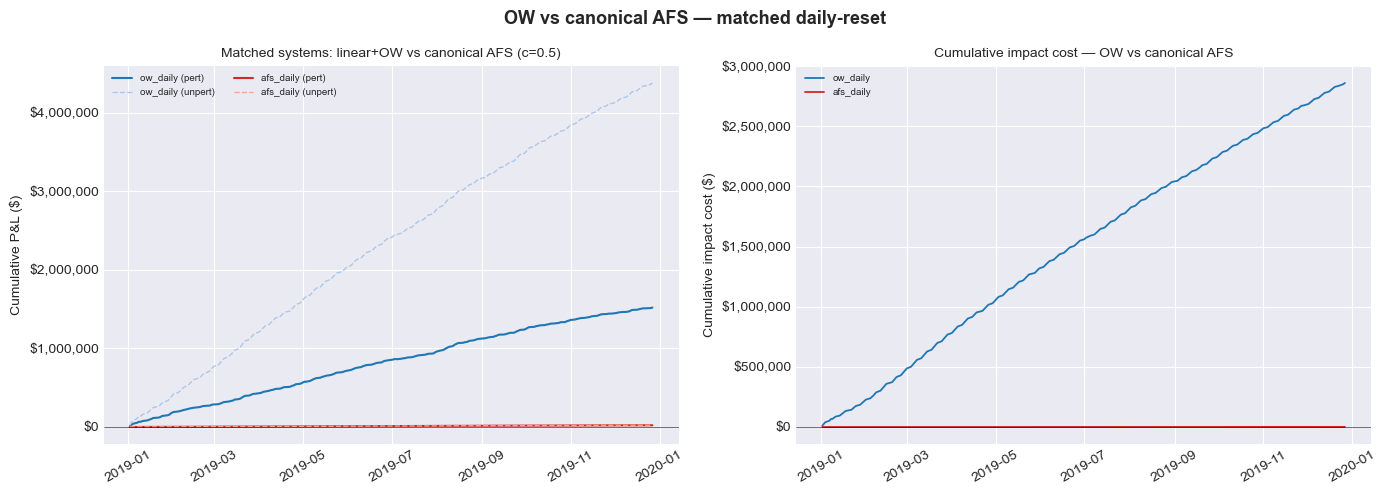

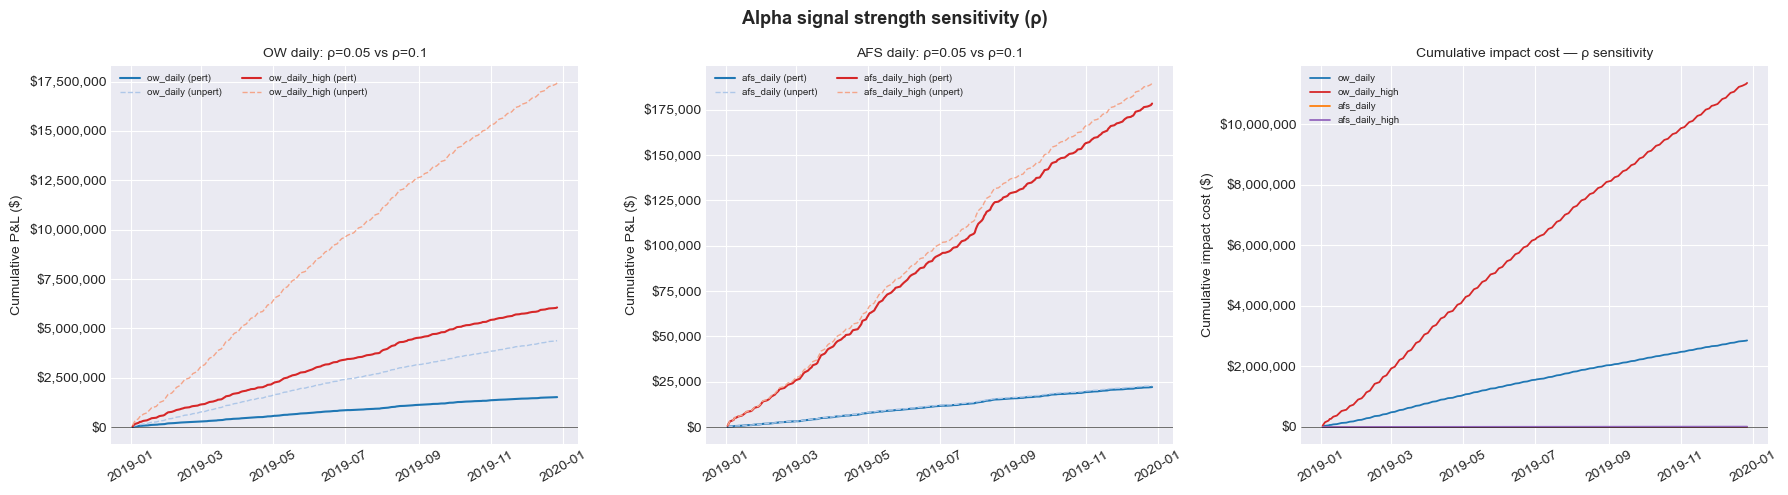

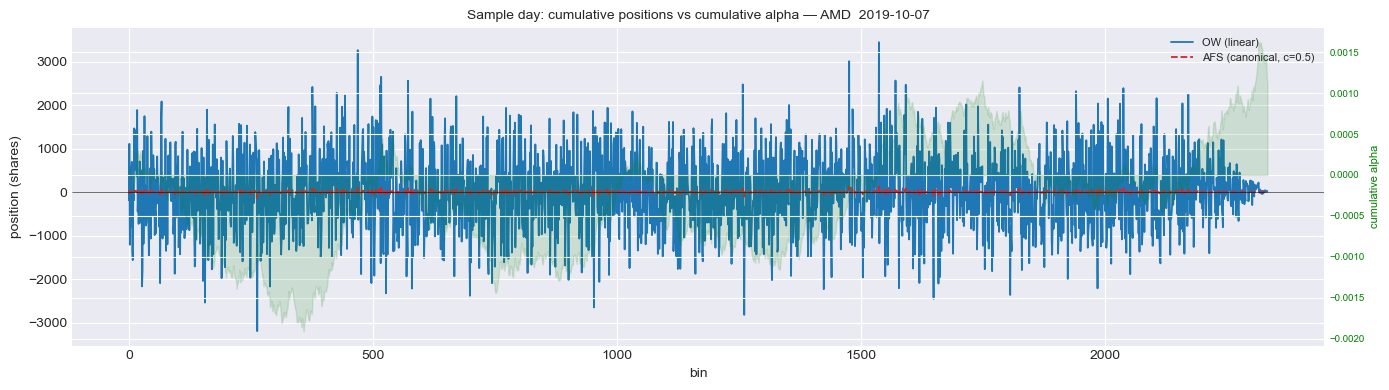

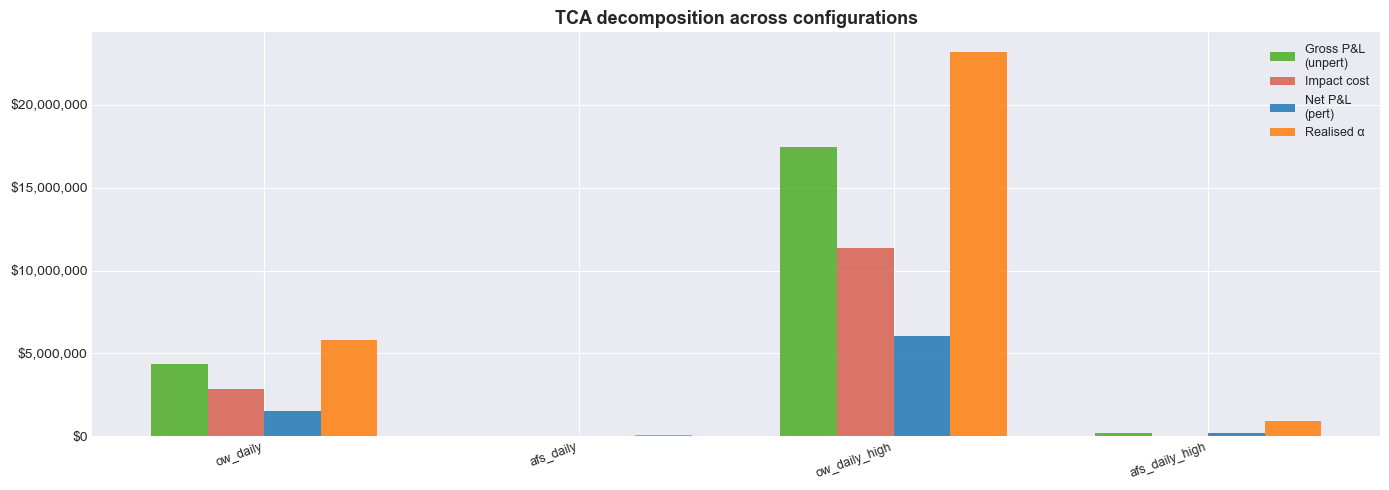

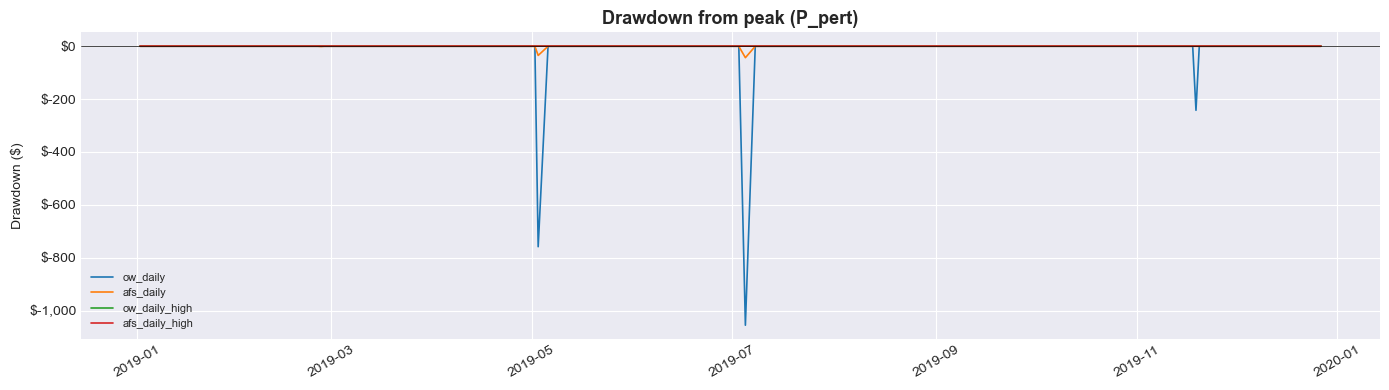

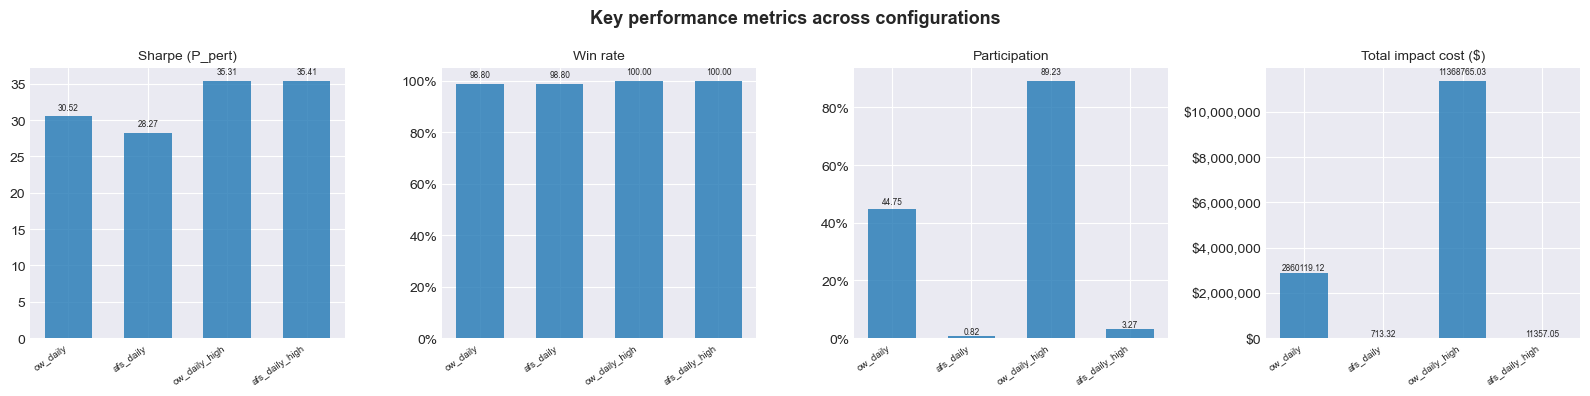

In [ ]:
import matplotlib.ticker as mtick


# ─── helpers ──────────────────────────────────────────────────────────────────
def _cum(name, col="pnl_pert"):
    return pi.cumulative_pnl(runs[name].daily, col)


_CA = ("#1f77b4", "#aec7e8")  # pert / unpert for run A
_CB = ("#d62728", "#f4a58a")  # pert / unpert for run B
_IMPACT_PALETTE = ["#1f77b4", "#d62728", "#ff7f0e", "#9467bd", "#2ca02c", "#8c564b"]


def _pair_ax(ax, nameA, nameB, title):
    for name, (cp_col, cu_col) in [(nameA, _CA), (nameB, _CB)]:
        cp = _cum(name, "pnl_pert")
        cu = _cum(name, "pnl_unpert")
        ax.plot(cp.index, cp.values, color=cp_col, lw=1.5, label=f"{name} (pert)")
        ax.plot(
            cu.index, cu.values, color=cu_col, lw=1.0, ls="--", label=f"{name} (unpert)"
        )
    ax.axhline(0, color="k", lw=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Cumulative P&L ($)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7, ncol=2)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))


def _impact_ax(ax, names, title):
    for name, c in zip(names, _IMPACT_PALETTE):
        ci = _cum(name, "impact_cost")
        ax.plot(ci.index, ci.values, color=c, lw=1.3, label=name)
    ax.axhline(0, color="k", lw=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Cumulative impact cost ($)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))


# ─── Figure 1: carry-mode effect ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_pair_ax(axes[0], "ow_daily", "ow_multi", "OW: daily vs multi-day carry")
_pair_ax(axes[1], "afs_daily", "afs_multi", "AFS: daily vs multi-day carry")
_impact_ax(
    axes[2],
    ["ow_daily", "ow_multi", "afs_daily", "afs_multi"],
    "Cumulative impact cost — all carry variants",
)
fig.suptitle("Carry mode effect", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ─── Figure 2: strategy misspecification + model choice ───────────────────────
# afs_pi_ow_strat: TRUE market impact is AFS (√), but we optimise as if
# linear (OW). Left panel isolates the strategy-misspecification cost; right
# panel compares the two fully-matched systems.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_pair_ax(
    axes[0],
    "afs_daily",
    "afs_pi_ow_strat_daily",
    "√ market: correct AFS exec vs misspecified OW exec",
)
_pair_ax(axes[1], "ow_daily", "afs_daily", "Matched systems: linear+OW vs sqrt+AFS")
_impact_ax(
    axes[2],
    ["ow_daily", "afs_daily", "afs_pi_ow_strat_daily"],
    "Cumulative impact cost — strategy & model variants",
)
fig.suptitle("Strategy misspecification & model choice", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ─── Figure 3: alpha signal sensitivity (RHO vs RHO_HIGH) ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_pair_ax(axes[0], "ow_daily", "ow_daily_high", f"OW daily: ρ={RHO} vs ρ={RHO_HIGH}")
_pair_ax(axes[1], "afs_daily", "afs_daily_high", f"AFS daily: ρ={RHO} vs ρ={RHO_HIGH}")
_impact_ax(
    axes[2],
    ["ow_daily", "ow_daily_high", "afs_daily", "afs_daily_high"],
    "Cumulative impact cost — ρ sensitivity",
)
fig.suptitle("Alpha signal strength sensitivity (ρ)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ─── Figure 4: sample day — positions + cumulative alpha ──────────────────────
# Use the low-ρ alpha for the sample day (matches the base configs).
_s_stock = panel.stocks[0]
_s_alphas = _alpha_cache[(RHO, H_ALPHA_BINS, 42)]
_s_date = _s_alphas["date"].iloc[len(_s_alphas) // 2]
_s_mask = (_s_alphas["stock"] == _s_stock) & (_s_alphas["date"] == _s_date)
_s_alpha = _s_alphas.loc[_s_mask, "alpha"].values
_s_cum_alpha = np.cumsum(_s_alpha)
_s_stats = daily_stats.loc[(_s_stock, _s_date)]

_day_pairs = [
    (
        "afs_daily",
        pi.afs_optimal_strategy,
        lam_lookup_daily["sqrt"][_s_stock],
        "afs_pi_ow_strat_daily",
        pi.ow_optimal_strategy,
        lam_lookup_daily["sqrt"][_s_stock],
        "√ market: AFS exec (correct) vs OW exec (misspec.)",
    ),
    (
        "ow_daily",
        pi.ow_optimal_strategy,
        lam_lookup_daily["linear"][_s_stock],
        "afs_daily",
        pi.afs_optimal_strategy,
        lam_lookup_daily["sqrt"][_s_stock],
        "Matched systems: linear+OW vs sqrt+AFS",
    ),
]

fig, axes = plt.subplots(1, len(_day_pairs), figsize=(15, 4))
for ax, (nA, fnA, lamA, nB, fnB, lamB, title) in zip(axes, _day_pairs):
    posA = np.cumsum(fnA(_s_alpha, _s_stats["sigma"], _s_stats["ADV"], lamA, H_star))
    posB = np.cumsum(fnB(_s_alpha, _s_stats["sigma"], _s_stats["ADV"], lamB, H_star))
    ax2 = ax.twinx()
    ax2.fill_between(range(len(_s_cum_alpha)), _s_cum_alpha, alpha=0.15, color="green")
    ax2.set_ylabel("cumulative alpha", color="green", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="green", labelsize=7)
    ax.plot(posA, color=_CA[0], lw=1.3, label=nA)
    ax.plot(posB, color=_CB[0], lw=1.3, ls="--", label=nB)
    ax.axhline(0, color="k", lw=0.4)
    ax.set_xlabel("bin")
    ax.set_ylabel("position (shares)")
    ax.set_title(f"{title}\n{_s_stock}  {_s_date.date()}", fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle(
    "Sample day: cumulative positions vs cumulative alpha",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# ─── Figure 5: TCA decomposition bar chart ────────────────────────────────────
_tca = pd.DataFrame({n: pi.tca_summary(r.tca) for n, r in runs.items()}).T
_tca_cols = ["gross_pnl", "impact_cost", "net_pnl", "realised_alpha"]
_tca_labels = ["Gross P&L\n(unpert)", "Impact cost", "Net P&L\n(pert)", "Realised α"]
_tca_colors = ["#4dac26", "#d6604d", "#1f77b4", "#ff7f0e"]

_x, _w = np.arange(len(_tca)), 0.18
fig, ax = plt.subplots(figsize=(14, 5))
for i, (col, lbl, c) in enumerate(zip(_tca_cols, _tca_labels, _tca_colors)):
    ax.bar(_x + i * _w, _tca[col], _w, label=lbl, color=c, alpha=0.85)
ax.set_xticks(_x + 1.5 * _w)
ax.set_xticklabels(_tca.index, rotation=20, ha="right", fontsize=9)
ax.axhline(0, color="k", lw=0.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))
ax.set_title("TCA decomposition across configurations", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ─── Figure 6: drawdown from peak ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for name in runs:
    c = _cum(name, "pnl_pert")
    ax.plot(c.index, (c - c.cummax()).values, lw=1.2, label=name)
ax.axhline(0, color="k", lw=0.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))
ax.set_title("Drawdown from peak (P_pert)", fontsize=13, fontweight="bold")
ax.set_ylabel("Drawdown ($)")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ─── Figure 7: key performance metrics ───────────────────────────────────────
_met_specs = [
    ("sharpe_pert", "Sharpe (P_pert)", 1, None),
    ("win_rate", "Win rate", 100, "%"),
    ("realized_participation", "Participation", 100, "%"),
    ("total_impact_cost", "Total impact cost ($)", 1, "$"),
]
_names = list(runs.keys())
_x2 = np.arange(len(_names))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (metric, lbl, scale, fmt) in zip(axes, _met_specs):
    vals = [runs[n].metrics[metric] * scale for n in _names]
    bars = ax.bar(_x2, vals, color="#1f77b4", alpha=0.8, width=0.6)
    ax.set_xticks(_x2)
    ax.set_xticklabels(_names, rotation=35, ha="right", fontsize=7)
    ax.set_title(lbl, fontsize=10)
    if fmt == "%":
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    elif fmt == "$":
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))
    for bar, v in zip(bars, vals):
        va = "bottom" if v >= 0 else "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * (1.02 if v >= 0 else 0.98),
            f"{v:.2f}",
            ha="center",
            va=va,
            fontsize=6,
        )
fig.suptitle(
    "Key performance metrics across configurations", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 7.1 Comparison table


In [21]:
comparison = pd.DataFrame({name: r.metrics for name, r in runs.items()}).T
comparison[
    [
        "n_days",
        "sharpe_pert",
        "sharpe_unpert",
        "sharpe_mid_raw",
        "total_pnl_pert",
        "total_pnl_unpert",
        "total_pnl_mid_raw",
        "total_impact_cost",
        "realized_participation",
        "flow_flag_count",
        "max_drawdown",
        "max_impact_dislocation",
        "win_rate",
    ]
].round(4)


,n_days,sharpe_pert,sharpe_unpert,sharpe_mid_raw,total_pnl_pert,total_pnl_unpert,total_pnl_mid_raw,total_impact_cost,realized_participation,flow_flag_count,max_drawdown,max_impact_dislocation,win_rate
ow_daily,250,4.368414,36.732904,2.97966,68317.180455,604336.805478,32416.120036,536019.625024,0.191747,996859,-6540.067927,0.000076,0.644
afs_daily,250,3.308602,3.616476,2.676711,532.593475,582.261896,362.647453,49.668422,0.002032,418862,-158.788581,0.000058,0.612
ow_daily_high,250,12.457981,77.09842,9.652998,589237.007999,5409715.019501,312076.350087,4820478.011502,0.575022,2032255,-8401.154348,0.00023,0.8
afs_daily_high,250,10.268164,13.011647,8.691111,14676.968658,18688.80388,10408.78217,4011.835222,0.01828,522201,-573.29057,0.000247,0.764


### 7.2 TCA decomposition


In [22]:
tca_rows = {name: pi.tca_summary(r.tca) for name, r in runs.items()}
tca_summary_df = pd.DataFrame(tca_rows).T
tca_summary_df[
    [
        "gross_pnl",
        "impact_cost",
        "net_pnl",
        "mid_raw_pnl",
        "predicted_alpha",
        "realised_alpha",
        "turnover",
        "gross_notional",
        "flow_flag_count",
    ]
].round(2)


,gross_pnl,impact_cost,net_pnl,mid_raw_pnl,predicted_alpha,realised_alpha,turnover,gross_notional,flow_flag_count
ow_daily,604336.81,536019.63,68317.18,32416.12,1086088.20,1172546.73,7.661122e+08,8.644165e+10,996859.0
afs_daily,582.26,49.67,532.59,362.65,12548.17,12864.61,8.117753e+06,9.164933e+08,418862.0
ow_daily_high,5409715.02,4820478.01,589237.01,312076.35,9767294.36,10389806.94,2.297456e+09,2.592248e+11,2032255.0
afs_daily_high,18688.80,4011.84,14676.97,10408.78,338531.62,342897.14,7.303794e+07,8.245721e+09,522201.0


### 7.3 Cumulative P&L — head-to-head


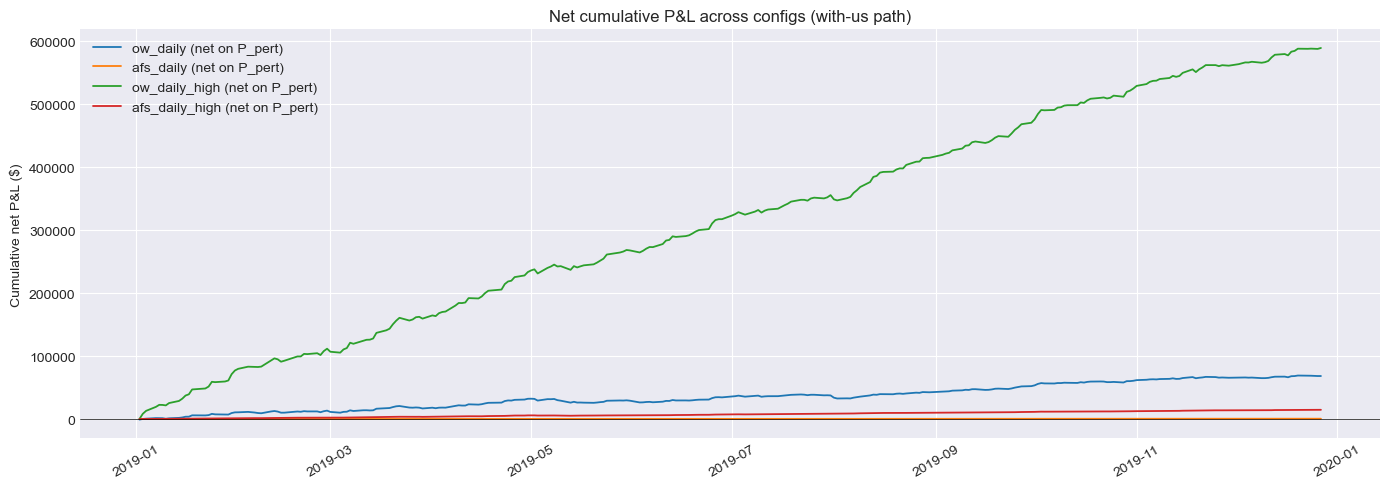

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))
for name, out in runs.items():
    cum = pi.cumulative_pnl(out.daily, "pnl_pert")
    ax.plot(cum.index, cum.values, label=f"{name} (net on P_pert)", lw=1.3)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative net P&L ($)")
ax.set_title("Net cumulative P&L across configs (with-us path)")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### 7.4 Per-run artifacts

Each run wrote its plots, tables, config snapshot, and a sample price-path chart to `saved/<name>/`. The sample chart overlays observed mid, `P_unpert` (others only), `P_pert` (full aggregate), and the corresponding $g$ paths, so the perturbed/unperturbed comparison is directly accessible from `runs[name].paths["sample_price_paths_plot"]`.



=== saved/ow_daily/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  price_paths_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/afs_daily/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  price_paths_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/ow_daily_high/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  price_paths_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/afs_daily_high/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  price_paths_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

Sample perturbed/unperturbed price-path plots:
ow_daily: saved/ow_daily/price_p

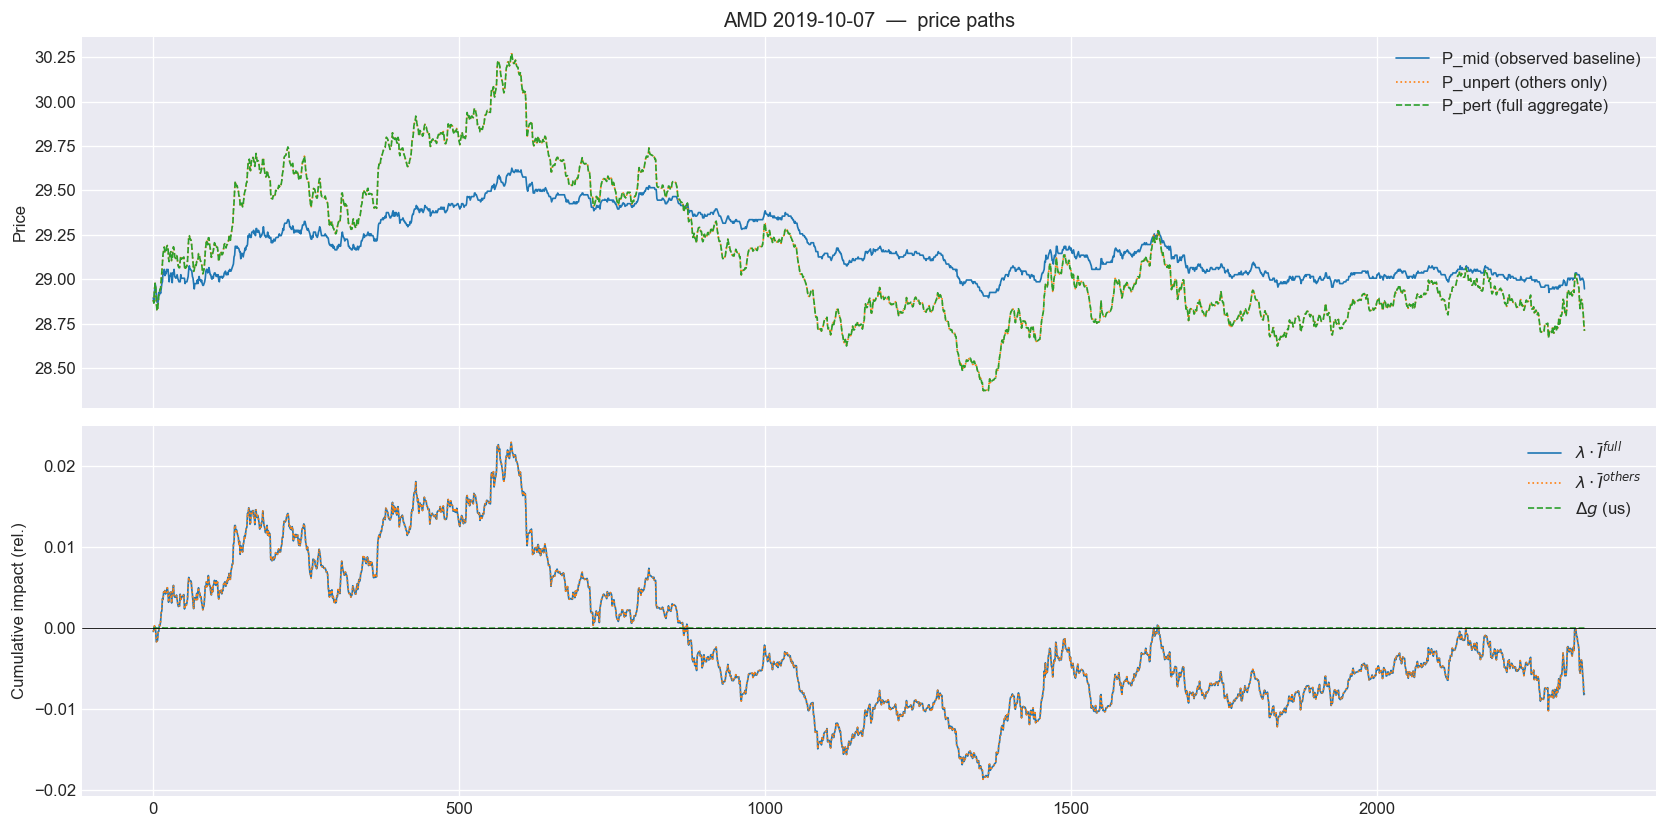

In [24]:
import os
from IPython.display import Image, display

for name in runs:
    files = sorted(os.listdir(runs[name].paths["dir"]))
    print(f"\n=== saved/{name}/ ===")
    for f in files:
        print(" ", f)

price_path_plots = {
    name: out.paths.get("sample_price_paths_plot")
    for name, out in runs.items()
    if out.paths.get("sample_price_paths_plot") is not None
}

print("\nSample perturbed/unperturbed price-path plots:")
for name, path in price_path_plots.items():
    print(f"{name}: {path}")

# Display one example inline; all runs expose their plot paths above.
if price_path_plots:
    first_name, first_path = next(iter(price_path_plots.items()))
    print(f"\nDisplaying {first_name} sample price paths:")
    display(Image(filename=str(first_path)))


## Summary

All pipeline logic lives in `src/price_impact/` and is unit-friendly — the notebook itself is just orchestration. To add a new backtest, build a new `BacktestConfig` and call `run_and_save`; to plug in a custom strategy or a fixed schedule (TWAP / VWAP), pass a `trade_provider` to `run_backtest` and bypass `run_and_save`'s OW/AFS dispatch.

The implemented accounting is: aggregate flow `q_agg` comes from the tape, our flow `q_us` comes from the strategy, and residual flow is `q_others = q_agg - q_us`. Under the Waelbroeck map $P=P_0(1+R+\lambda\bar I)$, the unperturbed path uses $\bar I(q_{others})$, the perturbed path uses $\bar I(q_{agg})$, P&L/impact uses the perturbed path, and participation is implied directly by `q_us` versus bin/day volume.

Outstanding work:

- Wire the **extended OW** closed form (time-dependent $\lambda(t)$) into `strategy.ext_ow_optimal_strategy_timedep_lambda`. The simulator already accepts a per-bin $\lambda$ array in `lam_t_lookup`.
- If you want fully no-us rolling signals rather than the current explicit hybrid, run a two-pass/fixed-point workflow that first constructs a `p_unpert` panel, then calls `compute_daily_stats(..., price_col="p_unpert")`, `create_synthetic_alpha(..., price_col="p_unpert")`, and the fitting helpers with `price_col="p_unpert"`.
